In [5]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
import shap
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import f_regression
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from joblib import Parallel, delayed
from scipy.stats import t
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Loading

In [7]:
import yaml

# --- Load configuration file ---
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

genetic_path = config["data"]["genetic_data"]
aroma_path = config["data"]["aroma_data"]
pc_df_path = config["data"]["sensory_pca_pc_df"]

genetic_data = pd.read_csv(genetic_path)
aroma_df = pd.read_csv(aroma_path)
pc_df = pd.read_csv(pc_df_path)


# --- Read CSV files ---
genetic_data = pd.read_csv(genetic_path)
aroma_df = pd.read_csv(aroma_path)
pc_df = pd.read_csv(pc_df_path)

# --- Display confirmations and previews ---
print(" Genetic data loaded from:", genetic_path)
print(genetic_data.head(5), "\n")

print(" Aroma data loaded from:", aroma_path)
print(aroma_df.head(5), "\n")

print(" PCA DataFrame loaded from:", pc_df_path)
pc_df.head(10)



 Genetic data loaded from: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/GeneMarkers-95 varieties 1.csv
   taglo_id  ATLANTIC_124776  ESCORT_159228  ARGOS_120931  ALTURAS_329540  \
0         7                0              0             0               0   
1        10                0              0             0               0   
2        13                0              0             0               0   
3        17                0              0             0               0   
4        21                0              0             0               0   

   ELMUNDO_835520  NADINE_241950  VIOLETQUEEN_3345402  DEODARA_513721  \
0               0              0                    0               0   
1               0              0                    0               0   
2               0              0                    0               0   
3               0              1                    0               0   
4               0              0        

,PC1,PC2,PC3,Variety,is_panel
0,7.797793,3.786555,-0.258905,ADORA,True
1,1.658722,-3.556767,1.917306,AGRIA,True
2,-1.051535,0.145923,3.496808,BERBER,True
3,1.577946,-3.208374,0.201062,BILDTSTAR,True
4,-2.531821,-0.997265,1.393942,BINTJE,True
5,2.147434,0.451214,-1.266318,CARRERA,True
6,-5.000658,2.756226,-0.678727,CECILE,True
7,-2.706073,0.430283,0.006144,CHALLENGER,True
8,3.236574,-0.560895,0.231981,DESIREE,True
9,2.316093,0.765887,0.141324,FABULA,True


# Data preparation

In [8]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import merge_genetic_aroma_sensory

# --- Load configuration ---
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Read input data ---
genetic_data = pd.read_csv(config["data"]["genetic_data"])
aroma_df = pd.read_csv(config["data"]["aroma_data"])
sensory_pcs = pd.read_csv(config["data"]["sensory_pca_pc_df"])

# --- Run merge function ---
merged_snp_aroma, merged_snp_sensory, merged_all = merge_genetic_aroma_sensory(
    genetic_data, aroma_df, sensory_pcs
)


 Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 95
  Dropped (all NaN): 0
  Final usable aroma columns: 95
  Sample aroma cols: ['(E)-2-Decenal', '(E)-2-Heptenal', '(E)-2-Hexenal', '(E, E)-2,4-Decadienal', '1,2-dimethoxy-Benzene', '1-Heptanol', '1-Hexanol, 2-ethyl-', '1-Nonanol']

# Sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']

# Merge results:
  Genetic + Aroma: (94, 262529)
  Genetic + Sensory: (94, 262437)
  Genetic + Aroma + Sensory: (94, 262532)


In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.graph_objects as go


def pca_biplot_aroma_interactive(
    aroma_df,
    n_components=2,
    scale_arrows=20,
    top_n=10,
    label_col="Variety",      # put your variety/sample column name here
    show_text=False,          # True = write labels on the plot (can get crowded)
    exclude_numeric_cols=None # list of numeric columns to exclude if needed
):
    # -------------------------
    # Pick labels (Variety/Sample) for points
    # -------------------------
    if label_col is not None and label_col in aroma_df.columns:
        labels = aroma_df[label_col].astype(str).tolist()
    else:
        labels = aroma_df.index.astype(str).tolist()

    # -------------------------
    # Select numeric VOC data + impute NaN
    # -------------------------
    X = aroma_df.select_dtypes(include=[np.number]).copy()

    if exclude_numeric_cols:
        X = X.drop(columns=[c for c in exclude_numeric_cols if c in X.columns], errors="ignore")

    if X.shape[1] == 0:
        raise ValueError("No numeric columns found for PCA after filtering/excluding columns.")

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    feature_names = X.columns.tolist()

    # -------------------------
    # Standardize
    # -------------------------
    X_scaled = StandardScaler().fit_transform(X)

    # -------------------------
    # PCA
    # -------------------------
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"])
    pca_df["label"] = labels

    # -------------------------
    # Loadings
    # -------------------------
    loadings = pd.DataFrame(
        pca.components_.T[:, :2],
        index=feature_names,
        columns=["PC1", "PC2"]
    )

    # -------------------------
    # Top compounds by loading strength
    # -------------------------
    strength = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)
    top = strength.sort_values(ascending=False).head(top_n).index

    print("\n===============================")
    print(f" TOP {top_n} AROMA COMPOUNDS (by |loading| in PC1/PC2)")
    print("===============================")
    print(top.tolist())

    # -------------------------
    # Plotly figure
    # -------------------------
    fig = go.Figure()

    point_mode = "markers+text" if show_text else "markers"
    fig.add_trace(go.Scatter(
        x=pca_df["PC1"],
        y=pca_df["PC2"],
        mode=point_mode,
        text=pca_df["label"] if show_text else None,
        hovertext=pca_df["label"],
        textposition="top center",
        marker=dict(size=7),
        hovertemplate="<b>%{hovertext}</b><br>PC1: %{x:.3f}<br>PC2: %{y:.3f}<extra></extra>"
    ))

    # Arrows for top compounds
    for comp in top:
        x = float(loadings.loc[comp, "PC1"]) * scale_arrows
        y = float(loadings.loc[comp, "PC2"]) * scale_arrows

        fig.add_trace(go.Scatter(
            x=[0, x],
            y=[0, y],
            mode="lines+markers+text",
            line=dict(width=3),
            marker=dict(size=4),
            text=[None, comp],
            textposition="top center",
            hovertemplate=(
                f"<b>{comp}</b>"
                f"<br>PC1 Loading: {loadings.loc[comp, 'PC1']:.3f}"
                f"<br>PC2 Loading: {loadings.loc[comp, 'PC2']:.3f}"
                "<extra></extra>"
            )
        ))

    fig.update_layout(
        title="Interactive PCA Biplot (Aroma/VOC)",
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
        width=900,
        height=700,
        showlegend=False
    )
    fig.update_xaxes(zeroline=True, zerolinewidth=1)
    fig.update_yaxes(zeroline=True, zerolinewidth=1)

    fig.show()
    return pca_df, loadings, top


# ---- Example usage ----
# If your variety names are in a column (recommended):
# pca_scores, loadings, top_compounds = pca_biplot_aroma_interactive(aroma_df, label_col="Variety")

# If your variety names are already the index:
# pca_scores, loadings, top_compounds = pca_biplot_aroma_interactive(aroma_df, label_col=None)

# Optional: hide on-plot text (cleaner) and only show names on hover:
pca_scores, loadings, top_compounds = pca_biplot_aroma_interactive(
    aroma_df,
    label_col="Variety",
    show_text=False,
    top_n=10,
    scale_arrows=20
)



 TOP 10 AROMA COMPOUNDS (by |loading| in PC1/PC2)
['Dimethyl trisulfide', 'Dimethyl sulfide', '2-Methylpropanal', 'Dimethyl disulfide', 'Decanal', '2-Propanone, 1-methoxy-', 'Heptanal', '3-Methylfuran', '3-Carene', 'Acetic acid, ethenyl ester']


# Exploratory analysis:

# 1.PCA of Genetic–Aroma Dataset


 COMPOUNDS HIGH IN ALTUS / FESTIN / AVARNA / ROYAL DONALD
GEN__287058    0.009043
GEN__260303    0.008986
GEN__260242    0.008986
GEN__260406    0.008986
GEN__260327    0.008986
GEN__260354    0.008986
GEN__260381    0.008986
GEN__260492    0.008986
GEN__260457    0.008986
GEN__260831    0.008986
GEN__260052    0.008986
GEN__260899    0.008986
GEN__260011    0.008986
GEN__260050    0.008986
GEN__260152    0.008986
Name: PC2, dtype: float64

 COMPOUNDS LOW IN THOSE (but high in other varieties)
GEN__250926   -0.008080
GEN__250925   -0.007775
GEN__256244   -0.007189
GEN__484384   -0.006846
GEN__281386   -0.006829
GEN__484447   -0.006615
GEN__283140   -0.006583
GEN__271250   -0.006492
GEN__250924   -0.006394
GEN__410194   -0.006394
GEN__484364   -0.006296
GEN__484416   -0.006280
GEN__484417   -0.006280
GEN__484448   -0.006280
GEN__407139   -0.006186
Name: PC2, dtype: float64

 ACTUALLY HIGHER IN TARGET GROUP (Mean concentration difference)
Tetradecane                            1.895666e

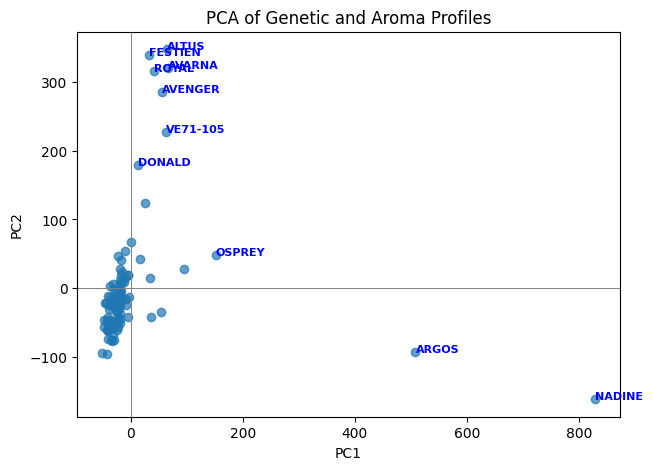

In [12]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import pca_with_feature_contribution,plot_pca

# pca_df, outliers, pca_model = perform_pca_with_outliers(
#     merged_snp_aroma,
#     n_components=3,
#     outlier_percent=5,
#     title="PCA of Genetic and Aroma Profiles in Potato Varieties"
# )
pca_df, loadings, difference = pca_with_feature_contribution(merged_snp_aroma)

# Optional: plot PCA
plot_pca(pca_df, merged_snp_aroma)


 TOP 10 MOST IMPORTANT COMPOUNDS
['GEN__355900', 'GEN__356111', 'GEN__356043', 'GEN__355992', 'GEN__355952', 'GEN__356271', 'GEN__356208', 'GEN__354835', 'GEN__355231', 'GEN__355133']


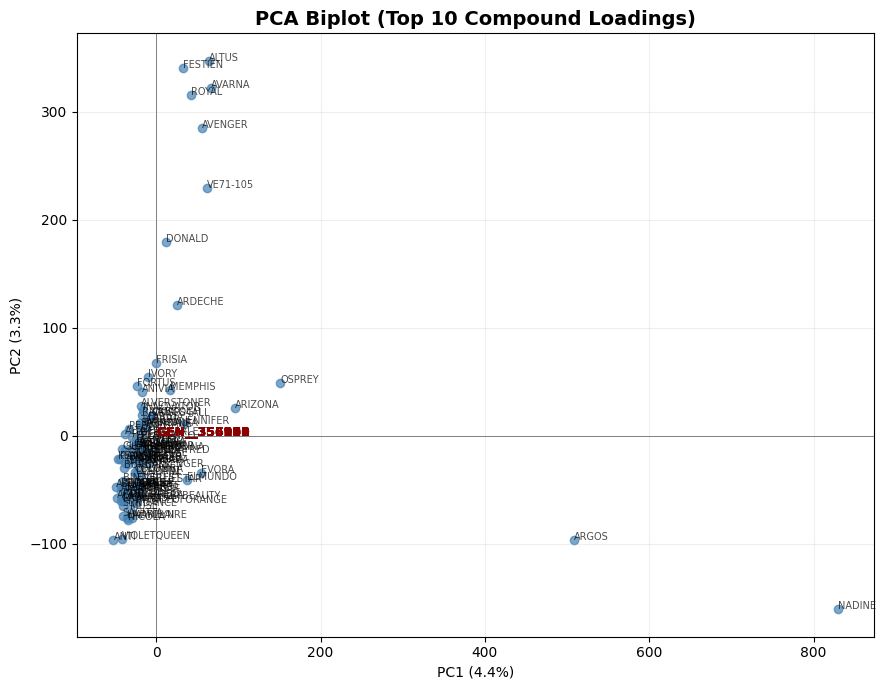

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def pca_biplot_top10(data, n_components=2, scale_arrows=30):
    """
    PCA Biplot showing ALL varieties but ONLY the TOP 10 strongest compounds.
    """

    # -------------------------
    # Select numeric data
    # -------------------------
    X = data.select_dtypes(include=[np.number])
    feature_names = X.columns.tolist()

    # -------------------------
    # Standardize
    # -------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -------------------------
    # PCA
    # -------------------------
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(X_scaled)

    # PCA scores
    pca_df = pd.DataFrame(
        pcs[:, :2],
        index=data.index,
        columns=["PC1", "PC2"]
    )

    # PCA loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=["PC1", "PC2"]
    )

    # ----------------------------------------------------
    # SELECT TOP 10 MOST IMPORTANT COMPOUNDS (FAST!)
    # ----------------------------------------------------
    loading_strength = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)
    top10_features = loading_strength.sort_values(ascending=False).head(10).index

    print("\n===============================")
    print(" TOP 10 MOST IMPORTANT COMPOUNDS")
    print("===============================")
    print(top10_features.tolist())

    # -------------------------
    # BIPLOT
    # -------------------------
    plt.figure(figsize=(9, 7))

    # Plot all varieties
    plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7, color="steelblue")

    # Label varieties
    for variety in pca_df.index:
        plt.text(
            pca_df.loc[variety, "PC1"],
            pca_df.loc[variety, "PC2"],
            variety,
            fontsize=7,
            alpha=0.7
        )

    # -------------------------
    # Plot only top 10 loading arrows
    # -------------------------
    for feature in top10_features:
        x = loadings.loc[feature, "PC1"] * scale_arrows
        y = loadings.loc[feature, "PC2"] * scale_arrows

        plt.arrow(
            0, 0, x, y,
            color='red', alpha=0.7,
            head_width=0.05
        )
        plt.text(
            x * 1.1,
            y * 1.1,
            feature,
            color='darkred',
            fontsize=9,
            fontweight='bold'
        )

    # -------------------------
    # Styling
    # -------------------------
    plt.axhline(0, color='grey', lw=0.7)
    plt.axvline(0, color='grey', lw=0.7)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("PCA Biplot (Top 10 Compound Loadings)", fontsize=14, weight="bold")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return pca_df, loadings, top10_features
pca_scores, pca_loadings, top10 = pca_biplot_top10(merged_snp_aroma)


# 2.PLSR on Genetic–Aroma Dataset

Top Influential Genes:
 GEN__203314    0.008664
GEN__523258    0.008137
GEN__522712    0.008137
GEN__523412    0.008137
GEN__523517    0.008137
GEN__522753    0.008137
GEN__523315    0.008137
GEN__523460    0.008137
GEN__523214    0.008137
GEN__522993    0.008137
dtype: float64

Top Influential Aroma Compounds:
 2,4-Nonadienal                         0.012784
1-Penten-3-one                         0.012563
2-Undecenal                            0.012395
Octanoic acid                          0.012358
2-Nonanone                             0.012331
Undecanal                              0.012291
Hexanoic acid, methyl ester            0.012226
nonanoic acid                          0.012216
Decanoic acid                          0.012202
2-Decanone                             0.012188
Hexadecane                             0.012159
Dodecanal                              0.012143
1-Nonanol                              0.012032
Tridecanal                             0.012016
2(3H)-Furanone

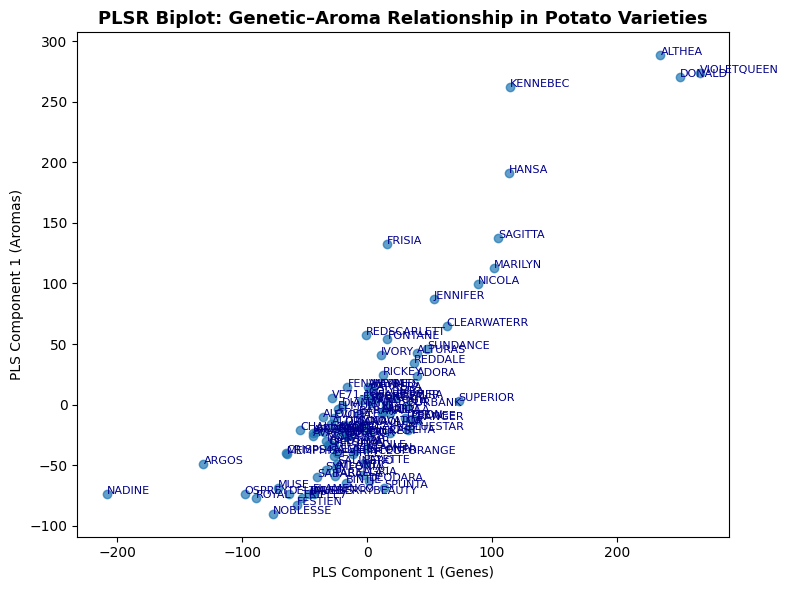


Explained variance (X, Y): (262434, 2), (95, 2)
Number of varieties analyzed: 94


In [14]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import analyze_gene_aroma_plsr
# Extract genetic and aroma parts from merged dataset
gd = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c.startswith("GEN__")]]
A = merged_snp_aroma[[c for c in merged_snp_aroma.columns if not c.startswith("GEN__")]]



pls_model, top_genes, top_aromas = analyze_gene_aroma_plsr(
    merged_snp_aroma,
    n_components=2,
    top_genes=10,
    top_aromas=20
)


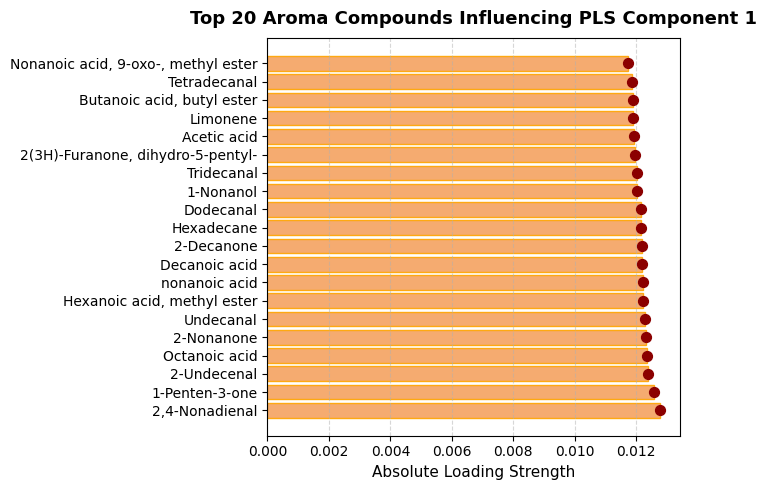

In [15]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_top_aroma_loadings_horizontal
plot_top_aroma_loadings_horizontal(top_aromas)


# 3.HCA (Ward, Euclidean) on SNP-linked aroma profiles (EDA)

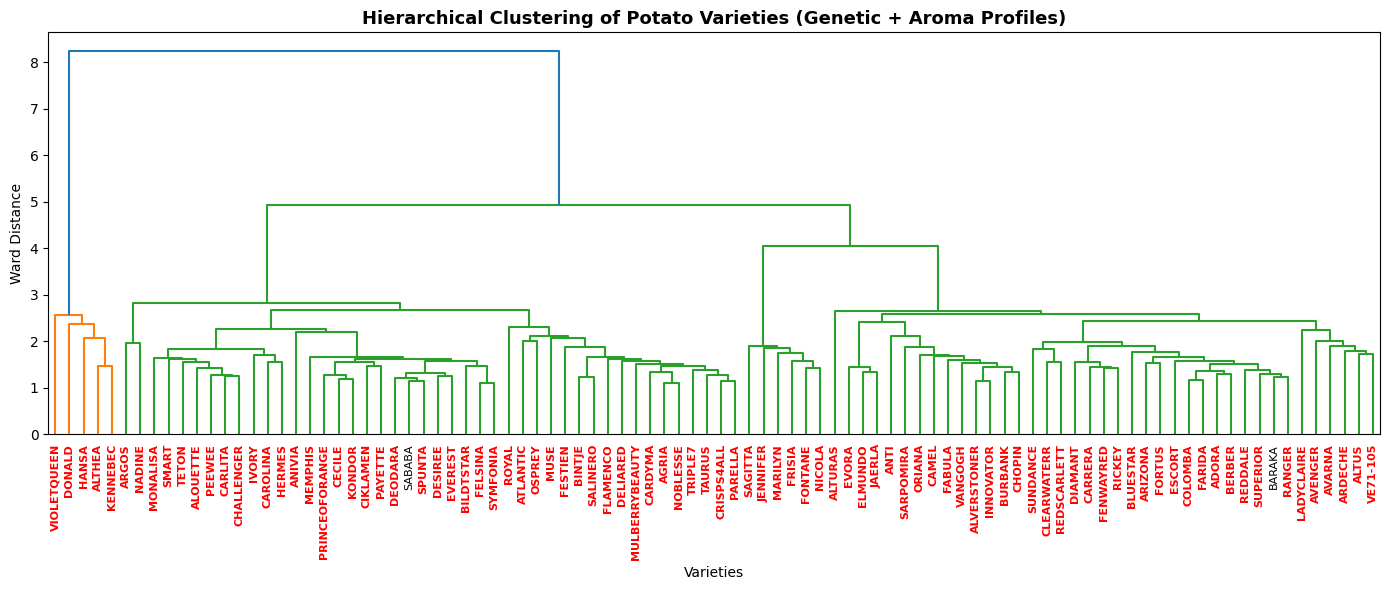

In [17]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_balanced_dendrogram_snp_aroma

Z = plot_balanced_dendrogram_snp_aroma(
    merged_snp_aroma,
    highlight_varieties='NotImplemented',
    title="Hierarchical Clustering of Potato Varieties (Genetic + Aroma Profiles)"
)


# 1. PCA of  Genetic–Sensory dataset

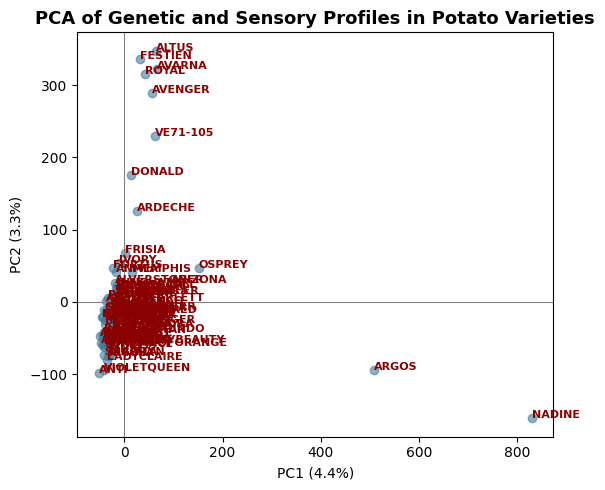

 PCA completed with 2 components.
Explained variance ratio (PC1+PC2): 7.61%
Outliers detected (94): ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONER', 'ANIVIA', 'ANTI', 'ARDECHE', 'ARGOS', 'ARIZONA', 'ATLANTIC', 'AVARNA', 'AVENGER', 'BARAKA', 'BERBER', 'BILDTSTAR', 'BINTJE', 'BLUESTAR', 'BURBANK', 'CAMEL', 'CARDYMA', 'CARLITA', 'CAROLINA', 'CARRERA', 'CECILE', 'CHALLENGER', 'CHOPIN', 'CIKLAMEN', 'CLEARWATERR', 'COLOMBA', 'CRISPS4ALL', 'DELIARED', 'DEODARA', 'DESIREE', 'DIAMANT', 'DONALD', 'ELMUNDO', 'ESCORT', 'EVEREST', 'EVORA', 'FABULA', 'FARIDA', 'FELSINA', 'FENWAYRED', 'FESTIEN', 'FLAMENCO', 'FONTANE', 'FORTUS', 'FRISIA', 'HANSA', 'HERMES', 'INNOVATOR', 'IVORY', 'JAERLA', 'JENNIFER', 'KENNEBEC', 'KONDOR', 'LADYCLAIRE', 'MARILYN', 'MEMPHIS', 'MONALISA', 'MULBERRYBEAUTY', 'MUSE', 'NADINE', 'NICOLA', 'NOBLESSE', 'ORIANA', 'OSPREY', 'PARELLA', 'PAYETTE', 'PEEWEE', 'PRINCEOFORANGE', 'RANGER', 'REDDALE', 'REDSCARLETT', 'RICKEY', 'ROYAL', 'SABABA', 'SAGITTA', 'SALI

In [18]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_gene_sensory

pca_df, pca_model, outliers = perform_pca_gene_sensory(
    merged_snp_sensory,
    n_components=2,
    outlier_threshold_pc1=4,
    outlier_threshold_pc2=3,
    title="PCA of Genetic and Sensory Profiles in Potato Varieties"
)


# 2.PLSR on Genetic–Sensory Dataset

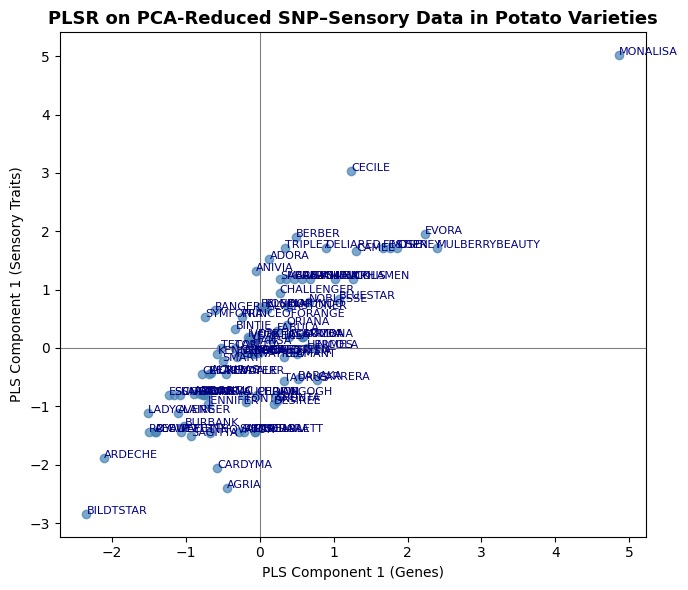

 PCA reduced SNPs to 50 components.
 PLSR computed 2 components.
Explained variance in PCA (first 3 comps): [0.04358077 0.03251347 0.02907683]
Samples plotted: 94 varieties.


In [19]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_plsr_gene_sensory


pca_model, pls_model, pls_scores_df = perform_pca_plsr_gene_sensory(
    merged_snp_sensory,
    n_pca_components=50,
    n_pls_components=2,
    title="PLSR on PCA-Reduced SNP–Sensory Data in Potato Varieties"
)


# 3.Hierarchical Clustering of Potato Varieties Based on Combined SNP and Sensory Profiles

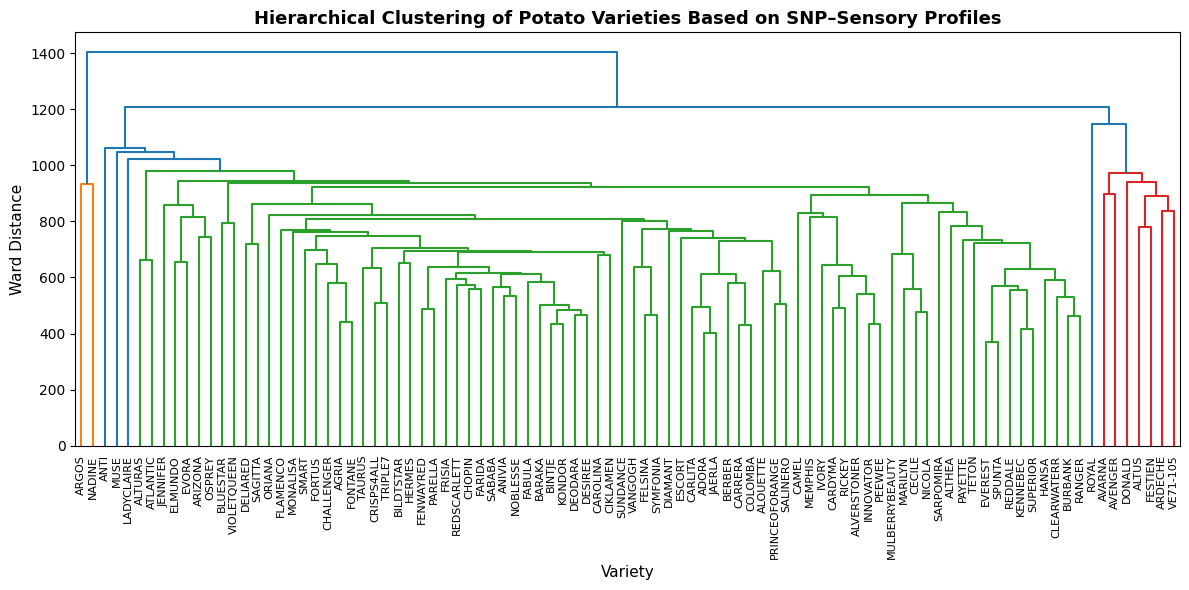

 HCA completed using ward linkage and euclidean distance.
Samples clustered: 94, Features used: 261113


In [20]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_hca_gene_sensory

Z = perform_hca_gene_sensory(
    merged_snp_sensory,
    metric="euclidean",
    method="ward",
    color_threshold_ratio=0.7,
    title="Hierarchical Clustering of Potato Varieties Based on SNP–Sensory Profiles"
)


# Feature selection

# Genome-Wide Association Study (GWAS) with FDR Correction and LD Pruning on Genetic–aroma Data

In [ ]:

# import yaml
# import importlib
# from scipy.stats import f
# from statsmodels.stats.multitest import multipletests
# from tqdm import tqdm
# import genemarker_module
# importlib.reload(genemarker_module)
# from genemarker_module import perform_gwas_for_traits

# # --- Load config ---
# with open("config.yaml", "r") as f:
#     config = yaml.safe_load(f)

# # --- Define path from config ---
# gwas_gene_aroma_output = config["data"]["gwas_output_gene_aroma"]

# # --- Run GWAS (this creates the CSV file) ---
# all_gwas_gene_aroma_df = perform_gwas_for_traits(
#     merged_df=merged_snp_aroma,
#     snp_prefix="GEN__",
#     output_path=gwas_gene_aroma_output,
#     ld_threshold=0.95,
#     top_n_snps=500
# )

# print(f"\n GWAS for Gene–Aroma completed successfully.")
# print(f"Results saved to: {gwas_gene_aroma_output}")




# GWas results

In [ ]:
import importlib
import yaml
import pandas as pd
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_full_report

# Load configuration
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Get GWAS file path
gwas_gene_aroma_output = config["data"]["gwas_output_gene_aroma"]

#  Read file into DataFrame
gwas_df = pd.read_csv(gwas_gene_aroma_output)

# Call plotting function with the DataFrame
plot_gwas_full_report(
    gwas_df,
    title_prefix="GWAS for Aroma Traits in Potato Varieties"
)
# file_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv"

# gwas_df= pd.read_csv(file_path)

# plt.figure(figsize=(10,5))
# plt.scatter(all_gwas_df.index, -np.log10(all_gwas_df['p_value']), c='gray', alpha=0.6, s=10)
# plt.scatter(all_gwas_df.index[all_gwas_df['p_fdr'] < 0.05],
#             -np.log10(all_gwas_df.loc[all_gwas_df['p_fdr'] < 0.05, 'p_value']),
#             c='red', s=15, label='Significant SNPs (FDR < 0.05)')
# plt.axhline(-np.log10(0.05), color='blue', linestyle='--')
# plt.xlabel("SNP Index")
# plt.ylabel("-log10(p-value)")
# plt.title("Manhattan Plot: GWAS for Aroma Traits")
# plt.legend()
# plt.show()



KeyboardInterrupt: 

# Multivariate Analysis of GWAS-Selected Features Using PCA, PLSR, and HCA

 Selected 69356 SNPs below FDR < 0.05


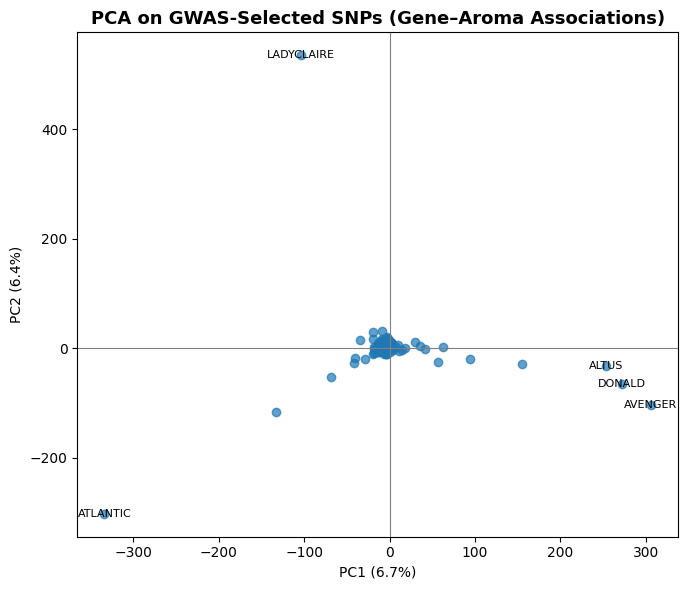

Explained variance: PC1 = 6.65%, PC2 = 6.43%


In [ ]:
import importlib
import yaml
import pandas as pd
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import pca_after_gwas_feature_selection_gene_aroma

# Run PCA after feature selection
pca_model, scores = pca_after_gwas_feature_selection_gene_aroma(
    merged_snp_aroma=merged_snp_aroma,
    gwas_df=gwas_df,
    fdr_threshold=0.05,
    n_components=2,
    title="PCA on GWAS-Selected SNPs (Gene–Aroma Associations)"
)

 Selected 69356 SNPs after GWAS feature selection (FDR < 0.05).


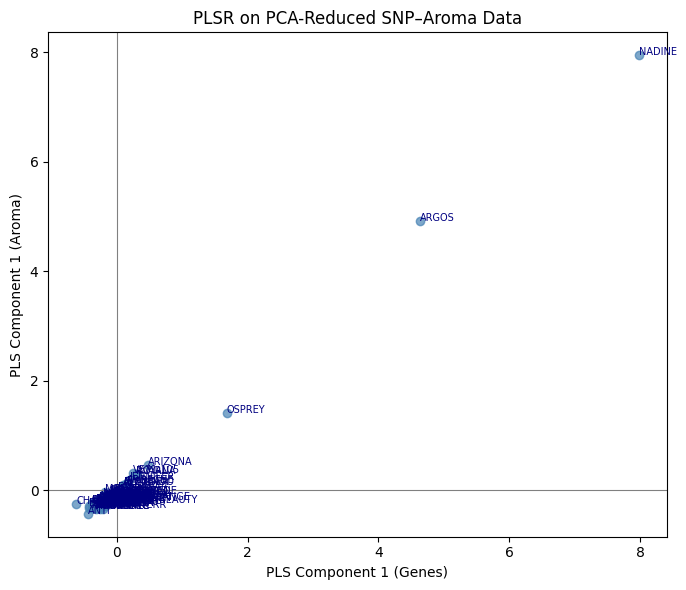

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt

def plsr_after_gwas_selection(
    merged_snp_aroma,
    gwas_file,
    fdr_col='p_fdr',
    snp_col='SNP',
    fdr_threshold=0.05,
    n_pca_components=50,
    n_pls_components=2,
    title="PLSR on PCA-Reduced SNP–Aroma Data"
):
    """
    Run PCA on GWAS-selected SNPs and perform PLSR with aroma traits.

    Parameters
    ----------
    merged_snp_aroma : pd.DataFrame
        Combined dataset of SNPs (GEN__ prefix) and aroma traits.
    gwas_file : str
        Path to the GWAS results CSV file.
    fdr_col : str, default='p_fdr'
        Column name for FDR-corrected p-values in the GWAS file.
    snp_col : str, default='SNP'
        Column name for SNP identifiers.
    fdr_threshold : float, default=0.05
        FDR threshold for selecting significant SNPs.
    n_pca_components : int, default=50
        Number of PCA components to retain.
    n_pls_components : int, default=2
        Number of PLS components.
    title : str, default="PLSR on PCA-Reduced SNP–Aroma Data"
        Title for the plot.

    Returns
    -------
    pca : PCA object
        Fitted PCA model.
    pls : PLSRegression object
        Fitted PLS model.
    X_scores, Y_scores : np.ndarray
        PLS component scores for SNP and aroma data.
    """

    # --- Load GWAS results ---
    gwas_df = pd.read_csv(gwas_file)

    # --- Select top SNPs based on FDR threshold ---
    top_snps = gwas_df.loc[gwas_df[fdr_col] < fdr_threshold, snp_col].unique().tolist()
    print(f" Selected {len(top_snps)} SNPs after GWAS feature selection (FDR < {fdr_threshold}).")

    if len(top_snps) == 0:
        print(" No SNPs passed the FDR threshold. Exiting.")
        return None, None, None, None

    # --- Prepare X (SNPs) and Y (aroma traits) ---
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    Y = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c not in top_snps]].select_dtypes(include=[np.number]).fillna(0)

    # --- Standardize ---
    X_scaled = StandardScaler().fit_transform(X)
    Y_scaled = StandardScaler().fit_transform(Y)

    # --- PCA reduction on SNPs ---
    pca = PCA(n_components=n_pca_components)
    X_reduced = pca.fit_transform(X_scaled)

    # --- PLS regression ---
    pls = PLSRegression(n_components=n_pls_components)
    pls.fit(X_reduced, Y_scaled)

    # --- Extract scores ---
    X_scores = pls.x_scores_
    Y_scores = pls.y_scores_

    # --- Plot (same as your version) ---
    plt.figure(figsize=(7, 6))
    plt.scatter(X_scores[:, 0], Y_scores[:, 0], alpha=0.7, color='steelblue')

    for i, name in enumerate(merged_snp_aroma.index):
        plt.text(X_scores[i, 0], Y_scores[i, 0], name, fontsize=7, color='navy')

    plt.axhline(0, color='gray', lw=0.8)
    plt.axvline(0, color='gray', lw=0.8)
    plt.xlabel("PLS Component 1 (Genes)")
    plt.ylabel("PLS Component 1 (Aroma)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return pca, pls, X_scores, Y_scores
pca_model, pls_model, X_scores, Y_scores = plsr_after_gwas_selection(
    merged_snp_aroma=merged_snp_aroma,
    gwas_file=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    fdr_threshold=0.05,
    n_pca_components=50,
    n_pls_components=2
)


 Selected 69356 SNPs after GWAS feature selection (FDR < 0.05).

 PLSR model fitted successfully.

 Found 3 key varieties: ['NADINE', 'ARGOS', 'OSPREY']

 Top 10 differentiating aroma compounds for NADINE:


Butanal, 3-methyl-         1.771176
Nonanal                    1.244649
Hexanol                    0.951093
2-Propanone, 1-methoxy-    0.677258
Acetophenone               0.667453
Pentanal                   0.419274
Hexanoic acid              0.417682
Octanoic acid              0.400339
Methyl butanoate           0.349708
Dimethyl trisulfide        0.322951
Name: NADINE, dtype: float64


 Top 10 differentiating aroma compounds for ARGOS:


Butanal, 3-methyl-         1.350496
Nonanal                    1.073687
Decanal                    1.061623
Octanal                    1.052723
Hexanol                    0.951093
Dimethyl trisulfide        0.848446
2-Propanone, 1-methoxy-    0.690182
Hexanal                    0.637450
Acetophenone               0.626286
Tetramethylpyrazine        0.549489
Name: ARGOS, dtype: float64


 Top 10 differentiating aroma compounds for OSPREY:


Nonanal                    1.988347
Tetramethylpyrazine        1.679730
Butanal, 3-methyl-         1.350496
Hexanol                    0.951093
Dimethyl trisulfide        0.848446
2-Propanone, 1-methoxy-    0.690182
Hexanal                    0.637450
Decanal                    0.487026
Pentanal                   0.419274
Octanoic acid              0.400339
Name: OSPREY, dtype: float64

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


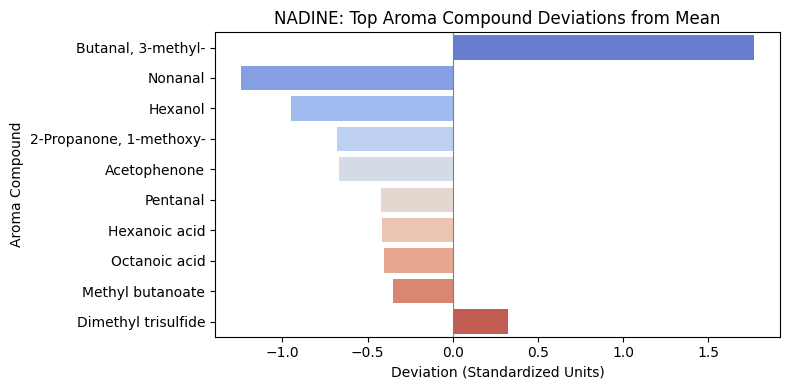

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


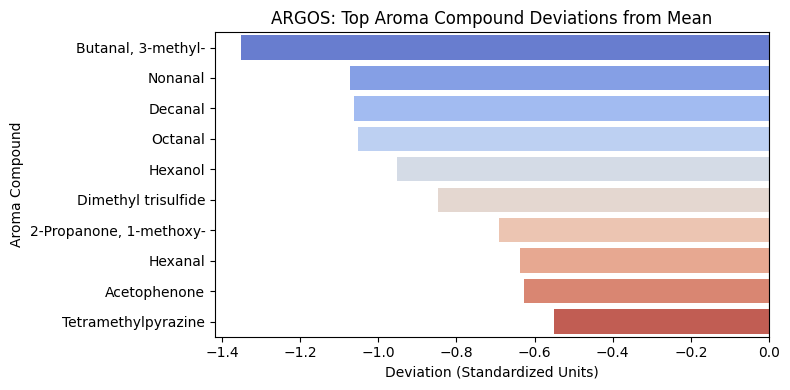

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


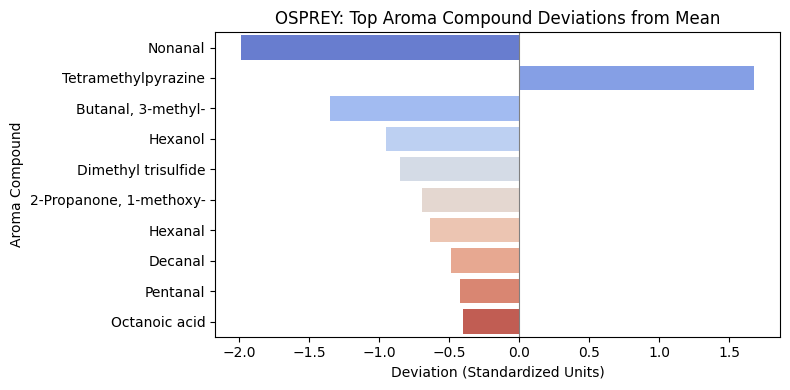


 Results saved as: key_variety_top_aroma_compounds.csv


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import analyze_key_variety_aroma_profiles

summary_df = analyze_key_variety_aroma_profiles(
    merged_snp_aroma=merged_snp_aroma,
    gwas_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    key_varieties=["NADINE", "ARGOS", "OSPREY"],
    top_n_compounds=10,
    save_path="key_variety_top_aroma_compounds.csv"
)


# Genome-Wide Association Study (GWAS) with FDR Correction and LD Pruning on Genetic–Sensory Data

In [ ]:

# import importlib
# import yaml
# import genemarker_module
# importlib.reload(genemarker_module)
# from genemarker_module import run_gwas_for_sensory_pcs

# # --- Load configuration file ---
# with open("config.yaml", "r") as f:
#     config = yaml.safe_load(f)

# # --- Extract GWAS output path from config ---
# gwas_output_sensory = config["data"]["gwas_output_sensory"]

# # --- Run GWAS using parameters from config ---
# all_gwas_df_sensory = run_gwas_for_sensory_pcs(
#     merged_snp_sensory=merged_snp_sensory,
#     snp_prefix="GEN__",
#     traits=["PC1", "PC2", "PC3"],
#     ld_threshold=0.95,
#     output_path=gwas_output_sensory
# )

# print(f"\n GWAS results for sensory PCs saved to:\n{gwas_output_sensory}")




# Define helper functions
def run_gwas(df, trait, snp_cols):
    """
    Run GWAS for a single trait.
    Returns a DataFrame with SNP, p_value, and p_fdr.
    """
    y = df[trait].astype(float).values
    n = len(y)
    gwas_results = []

    for snp in snp_cols:
        x = df[snp].fillna(df[snp].mode().iloc[0]).astype(float).values
        if x.std() == 0:
            continue
        x = (x - x.mean()) / (x.std() + 1e-6)

        r = np.corrcoef(x, y)[0, 1]
        if np.isnan(r):
            continue
        r = np.clip(r, -0.999999, 0.999999)

        F_val = (r**2) / ((1 - r**2) / (n - 2))
        p_val = f.sf(F_val, 1, n - 2)
        gwas_results.append((snp, p_val))

    gwas_df = pd.DataFrame(gwas_results, columns=["SNP", "p_value"])
    gwas_df["p_fdr"] = multipletests(gwas_df["p_value"], method="fdr_bh")[1]
    return gwas_df


def ld_prune(X_df, threshold=0.9, max_snps=2000):
    """
    Perform LD pruning on SNP matrix.
    Removes SNPs that are highly correlated (|r| > threshold).
    """
    X_df = X_df.loc[:, X_df.std() > 0]
    if X_df.shape[1] > max_snps:
        X_df = X_df.iloc[:, :max_snps]
    if X_df.shape[1] <= 1:
        return X_df

    corr = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X_df.drop(columns=to_drop)


# =====================================================
# 2. Prepare traits for sensory PCs
# =====================================================
snp_cols = [c for c in merged_snp_sensory.columns if c.startswith("GEN__")]
pcs = ["PC1", "PC2", "PC3"]
all_gwas_sensory = []

for trait in pcs:
    print(f"\n[trait] {trait}")
    gwas_df = run_gwas(merged_snp_sensory, trait, snp_cols)

    if gwas_df.empty:
        print("  No valid SNPs. Skipping.")
        continue

    top_snps = gwas_df.sort_values("p_fdr").head(500)["SNP"].tolist()
    if len(top_snps) == 0:
        print("  No significant SNPs. Skipping.")
        continue

    # SNP matrix
    X = merged_snp_sensory[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning. Skipping.")
        continue

    # add trait column before saving
    gwas_df["Trait"] = trait
    all_gwas_sensory.append(gwas_df)


# =====================================================
# 3. Save all GWAS results
# =====================================================
all_gwas_df_sensory = pd.concat(all_gwas_sensory, ignore_index=True)
all_gwas_df_sensory.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_sensory_PCs.csv", index=False)

print("\n All GWAS results for PC1–PC3 saved to gwas_sensory_PCs.csv")


NameError: name 'merged_snp_sensory' is not defined

# PCA Outlier Detection on GWAS-Selected SNPs

 No SNPs with FDR < 0.05. Using top 500 by p-value.


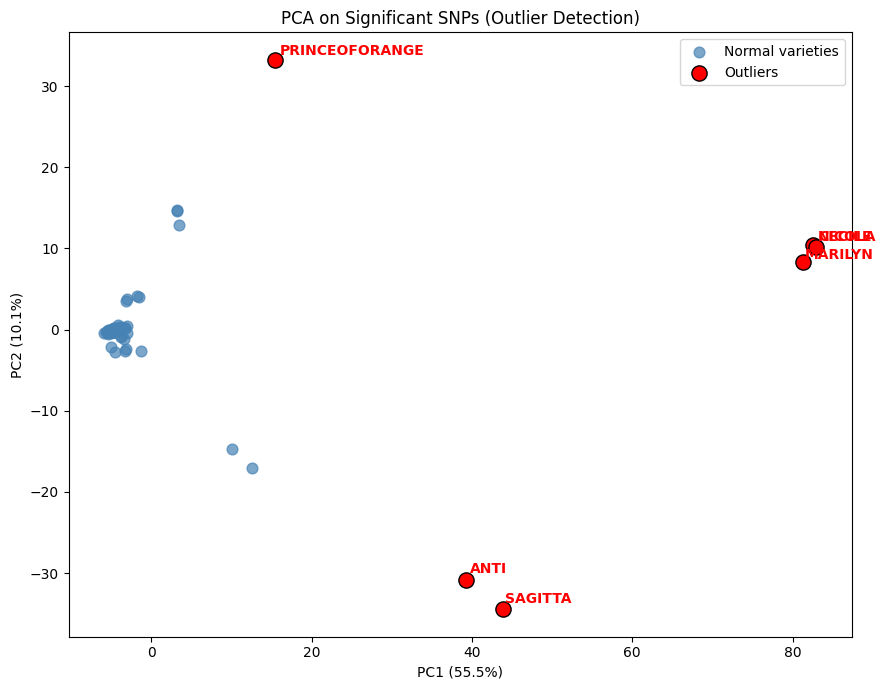

Detected PCA Outliers: ['ANTI', 'CECILE', 'MARILYN', 'NICOLA', 'PRINCEOFORANGE', 'SAGITTA']


In [ ]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  analyze_gwas_snps_pca


with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

results_pca = analyze_gwas_snps_pca(
    gwas_path=gwas_output_sensory,
    merged_snp_sensory=merged_snp_sensory
)

print("Detected PCA Outliers:", results_pca["pca_outliers"])




# Sensory Profile Comparison of Outlier Varieties

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import reconstruct_sensory_traits_from_pca


sensory_reconstructed_df = reconstruct_sensory_traits_from_pca(
    projection_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_projection.csv",
    loadings_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_loadings.csv",
    save_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv",
    n_components=3
)


 Reconstructed sensory traits using 3 PCs:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
Variety,,,,,,,,,,,,,,,,,,,,
ADORA,2.777227,3.021468,2.221376,2.850300,-1.066084,-0.847148,2.373826,2.495142,2.784747,3.016634,-1.006645,0.899148,1.878034,-0.157331,0.828773,1.786741,-0.069789,-0.149353,-0.225817,2.325663
AGRIA,-0.229637,-0.448615,0.509891,-0.827166,-0.731611,-1.171877,0.083648,0.310391,-0.388611,-1.042706,-1.130200,1.387898,-0.340720,-0.651435,1.694207,-0.093582,-0.849283,-1.680008,2.088016,0.320938
BERBER,-0.354242,-0.459819,0.098332,-0.640353,0.861787,0.459095,0.873152,0.428063,-0.596838,-0.754492,0.370748,-0.125063,-0.278329,1.418112,1.733750,-1.048533,1.192578,-0.023029,1.404938,-0.173067
BILDTSTAR,-0.143122,-0.293976,0.317844,-0.535582,-0.939388,-1.155316,-0.367521,0.003764,-0.178766,-0.677375,-1.078262,1.199855,-0.238350,-1.130382,0.698996,0.290940,-1.208747,-1.412395,1.204038,0.265307
BINTJE,-0.896907,-1.004481,-0.571348,-1.026723,0.614686,0.401464,-0.323025,-0.523106,-0.990835,-1.116110,0.412158,-0.289270,-0.621746,0.574778,0.430797,-0.885742,0.465161,0.026589,0.598025,-0.702797


 Saved reconstructed sensory traits → C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv


Detected PCA outliers for radar plot: ['ANTI', 'CECILE', 'MARILYN', 'NICOLA', 'PRINCEOFORANGE', 'SAGITTA']


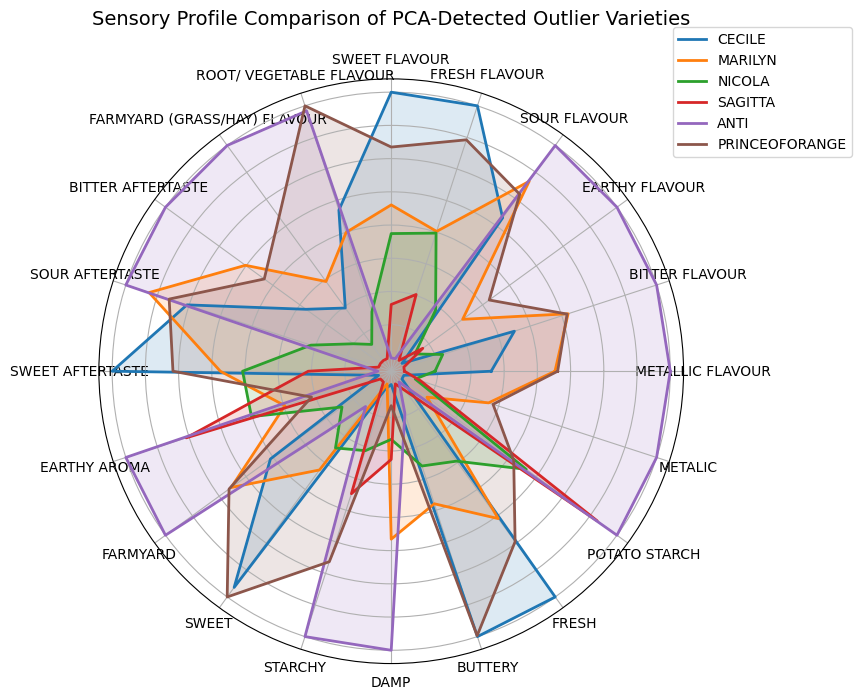

In [ ]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_sensory_profiles_of_pca_outliers

plot_sensory_profiles_of_pca_outliers(results_pca, sensory_reconstructed_df)

# Manhattan-Like Visualization of Sensory GWAS Results

Columns: ['SNP', 'p_value', 'p_fdr', 'Trait']


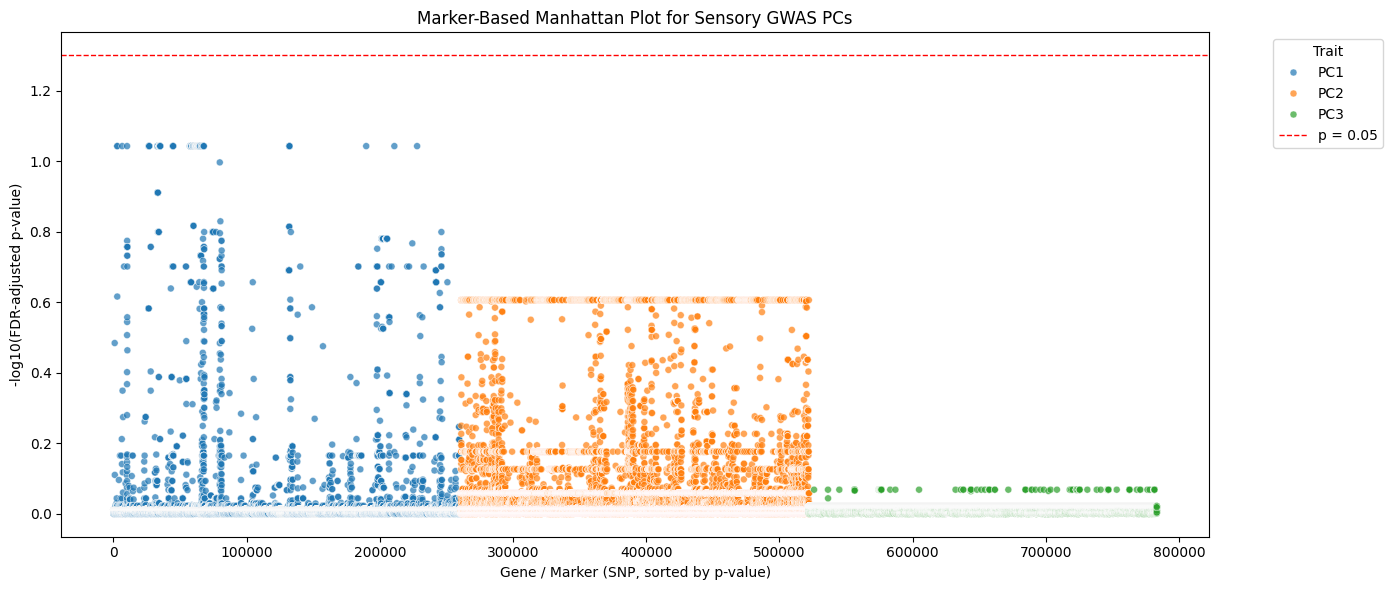

Min raw p-value: 1.4653148135385758e-05
Min FDR-adjusted p-value: 0.0905130918714166
Trait
PC1    261110
PC2    261110
PC3    261110
Name: count, dtype: int64
289 SNPs are FDR-significant


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_manhattan_like_gwas

# plot_manhattan_like_gwas(
#     r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/mixed biorep/gwas_sensory_PCs.csv"
# )


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
all_gwas_sensory = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_sensory_PCs.csv"
)

# Quick check of columns
print("Columns:", all_gwas_sensory.columns.tolist())

# --- Manhattan-like plot without chromosome info ---
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=all_gwas_sensory.sort_values("p_fdr"),
    x=range(len(all_gwas_sensory)),
    y=-np.log10(all_gwas_sensory["p_fdr"]),
    hue="Trait",
    palette="tab10",
    s=25,
    alpha=0.7
)

# Significance threshold line (p = 0.05)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="p = 0.05")

# Titles and labels
plt.title("Marker-Based Manhattan Plot for Sensory GWAS PCs")
plt.xlabel("Gene / Marker (SNP, sorted by p-value)")
plt.ylabel("-log10(FDR-adjusted p-value)")
plt.legend(title="Trait", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
print("Min raw p-value:", all_gwas_sensory["p_value"].min())
print("Min FDR-adjusted p-value:", all_gwas_sensory["p_fdr"].min())
print(all_gwas_sensory["Trait"].value_counts())
print((all_gwas_sensory["p_fdr"] < 0.1).sum(), "SNPs are FDR-significant")


# Volcano Plot Visualization of GWAS Results for Sensory Principal Components

 'effect_size' column not found — generated random values for visualization.


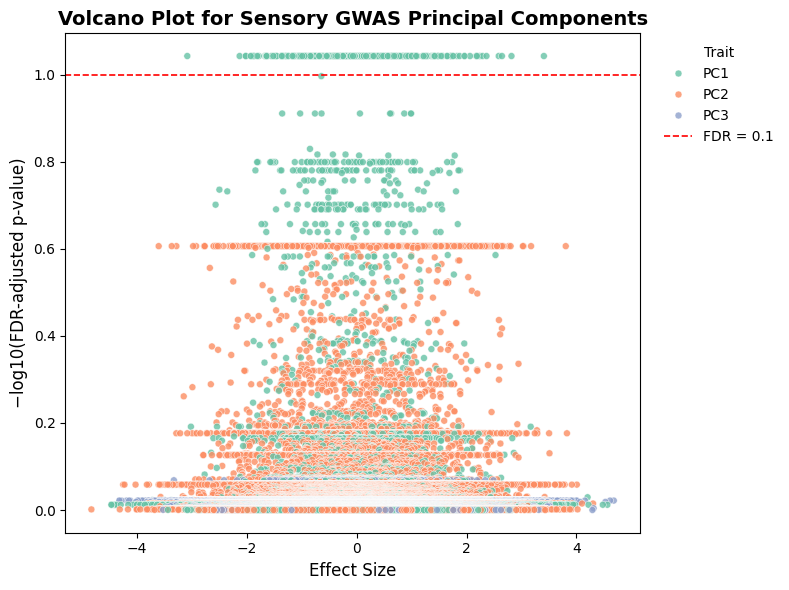

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_volcano

# --- Import and call the function ---
plot_gwas_volcano(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_sensory_PCs.csv",
    fdr_threshold=0.1
)



# QQ Plot for GWAS p-Value Distribution (Sensory Principal Components)

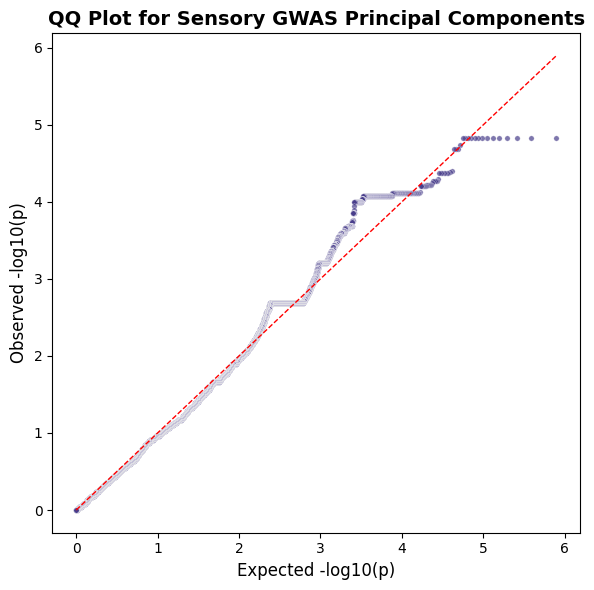

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_qq
plot_gwas_qq(all_gwas_df_sensory, pval_col="p_value")


# Comparison of Linear and Regularized Regression Models for GWAS Trait Prediction


[Linear Models — full] Trait: 1-Heptanol

[Linear Models — full] Trait: 1-Nonanol

[Linear Models — full] Trait: 1-Octen-3-ol

[Linear Models — full] Trait: 1-Phenylethanol

[Linear Models — full] Trait: 2,3-Pentanedione

[Linear Models — full] Trait: 2,4-Decadienal

[Linear Models — full] Trait: 2,6-Dimethylpyrazine

[Linear Models — full] Trait: 2-Isopropyl-3-methoxypyrazine

[Linear Models — full] Trait: 2-Methyl-1-propanol

[Linear Models — full] Trait: 2-Methylthiazole

[Linear Models — full] Trait: 2-Nonanone

[Linear Models — full] Trait: 2-Propanone, 1-methoxy-

[Linear Models — full] Trait: 3-Heptanone

[Linear Models — full] Trait: 3-Octanone

[Linear Models — full] Trait: Acetic acid

[Linear Models — full] Trait: Acetophenone

[Linear Models — full] Trait: Benzaldehyde

[Linear Models — full] Trait: Benzeneacetaldehyde

[Linear Models — full] Trait: Benzyl alcohol

[Linear Models — full] Trait: Butanal, 3-methyl-

[Linear Models — full] Trait: Butanoic acid

[Linear Models

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\linear_plot_full.png


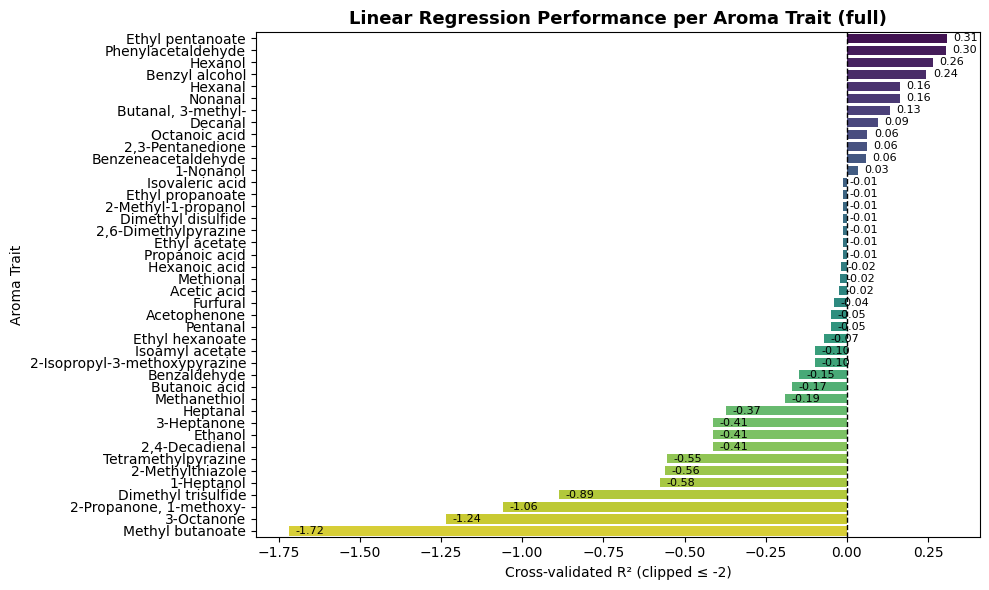

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\ridge_plot_full.png


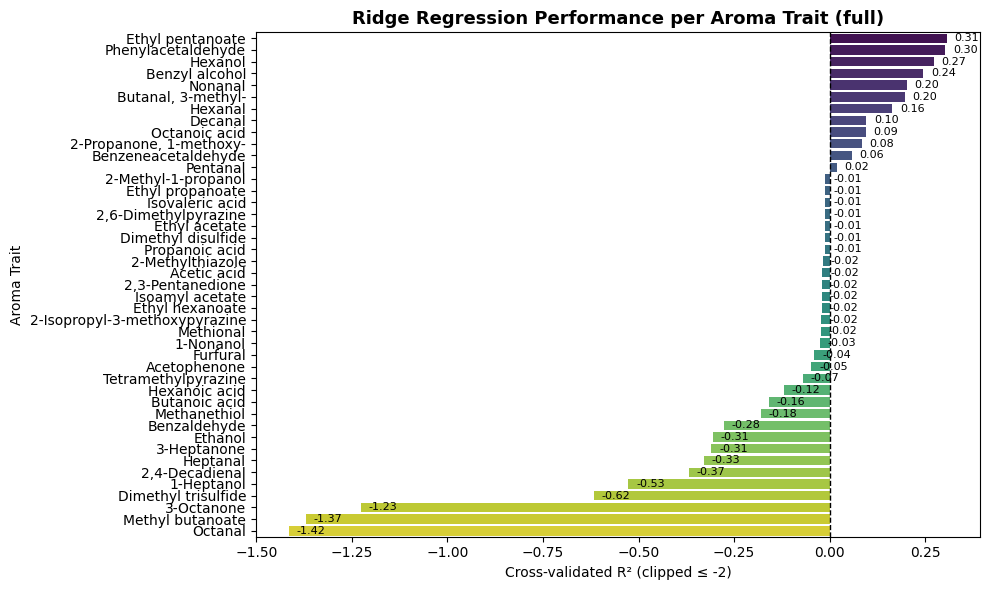

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\lasso_plot_full.png


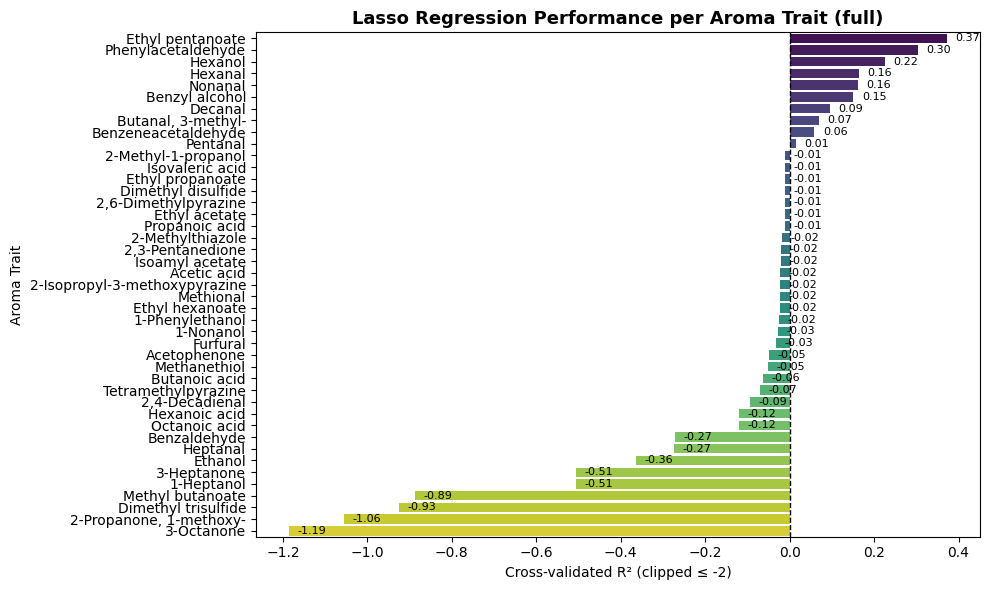

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\elasticnet_plot_full.png


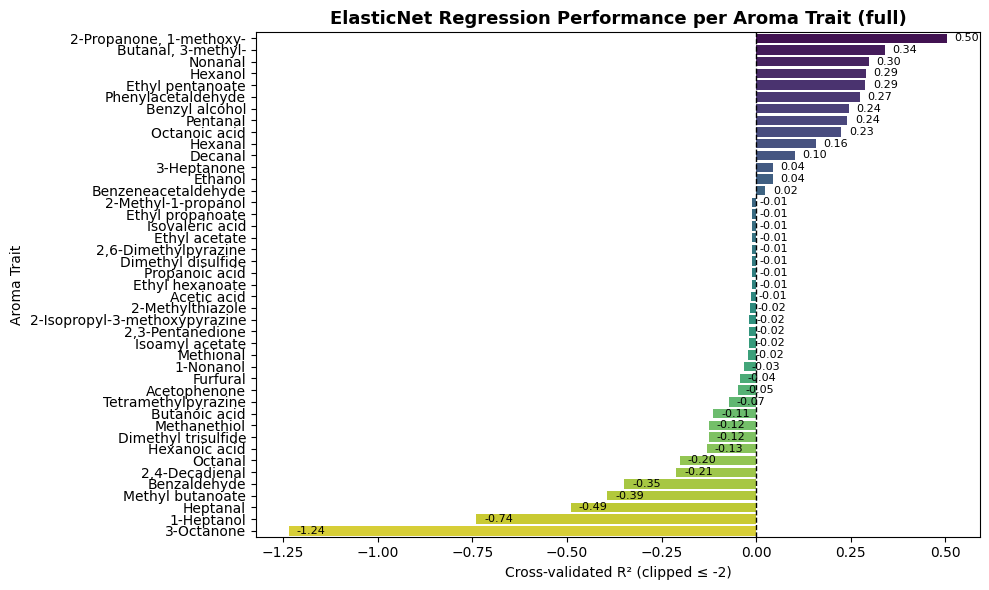

,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
0,1-Heptanol,Linear,1,-0.577092,0.770754,2.977106e+10,1.725429e+05,38515.787529
1,1-Heptanol,Ridge,1,-0.526657,0.770668,2.978215e+10,1.725751e+05,39177.064522
2,1-Heptanol,Lasso,1,-0.505721,0.770754,2.977106e+10,1.725429e+05,38515.847099
3,1-Heptanol,ElasticNet,1,-0.739134,0.757641,3.147399e+10,1.774091e+05,46709.897904
4,1-Nonanol,Linear,1,0.032972,0.984149,5.284044e+07,7.269143e+03,3191.317983
...,...,...,...,...,...,...,...,...
183,Propanoic acid,ElasticNet,1,-0.011111,0.982985,7.544000e+06,2.746634e+03,563.565590
184,Tetramethylpyrazine,Linear,1,-0.554890,0.463157,1.084807e+12,1.041541e+06,853614.631417
185,Tetramethylpyrazine,Ridge,1,-0.069328,0.463106,1.084911e+12,1.041591e+06,855075.016340
186,Tetramethylpyrazine,Lasso,1,-0.068970,0.463157,1.084807e+12,1.041541e+06,853614.674439


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_linear_models_gene_aroma


run_linear_models_gene_aroma(
    gwas_file= r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    snp_df= merged_snp_aroma,
    top_n_snps=200,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep",
    tag="full"
)


# Linear model after outlier removal

Detected 2 outliers (Z > 3): ['ARGOS', 'NADINE']
Remaining samples after outlier removal: 92
Remaining samples after outlier removal: 92

[Linear Models — outlier removed] Trait: 1-Heptanol

[Linear Models — outlier removed] Trait: 1-Nonanol

[Linear Models — outlier removed] Trait: 1-Octen-3-ol

[Linear Models — outlier removed] Trait: 1-Phenylethanol

[Linear Models — outlier removed] Trait: 2,3-Pentanedione

[Linear Models — outlier removed] Trait: 2,4-Decadienal

[Linear Models — outlier removed] Trait: 2,6-Dimethylpyrazine

[Linear Models — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[Linear Models — outlier removed] Trait: 2-Methyl-1-propanol

[Linear Models — outlier removed] Trait: 2-Methylthiazole

[Linear Models — outlier removed] Trait: 2-Nonanone

[Linear Models — outlier removed] Trait: 2-Propanone, 1-methoxy-

[Linear Models — outlier removed] Trait: 3-Heptanone

[Linear Models — outlier removed] Trait: 3-Octanone

[Linear Models — outlier removed] Trait: Aceti

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\linear_plot_outlier_removed.png


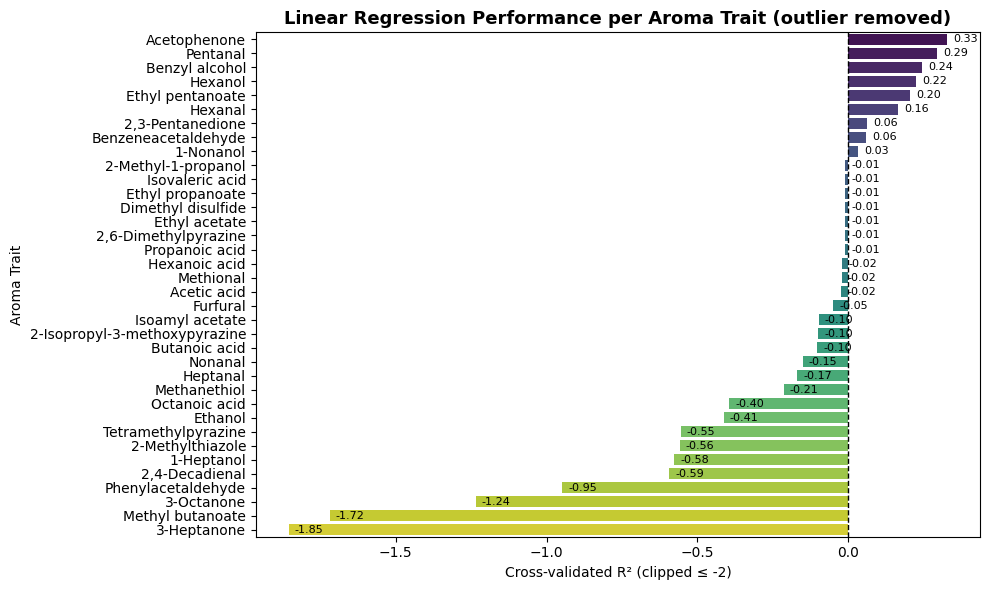

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\ridge_plot_outlier_removed.png


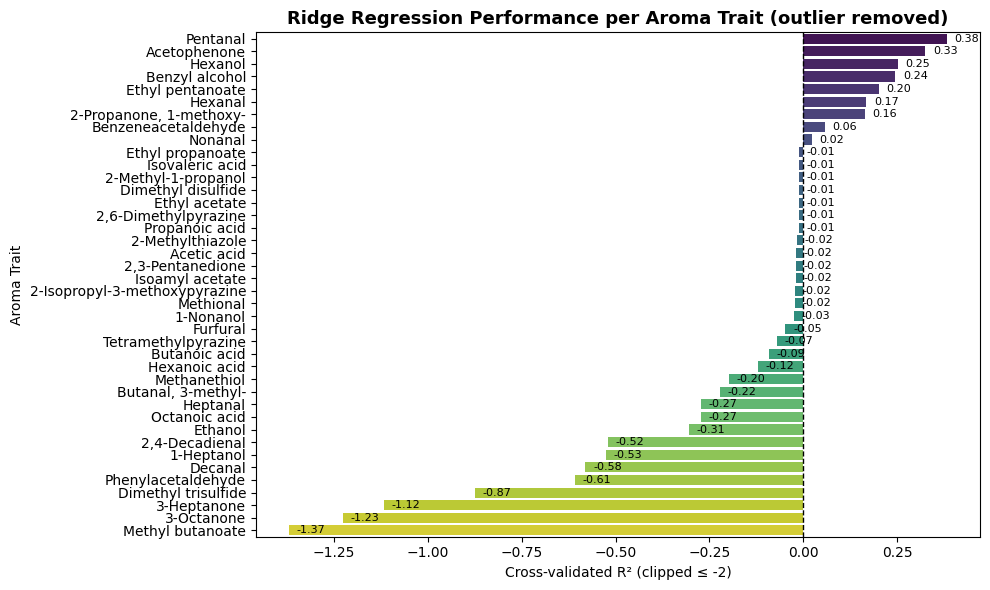

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\lasso_plot_outlier_removed.png


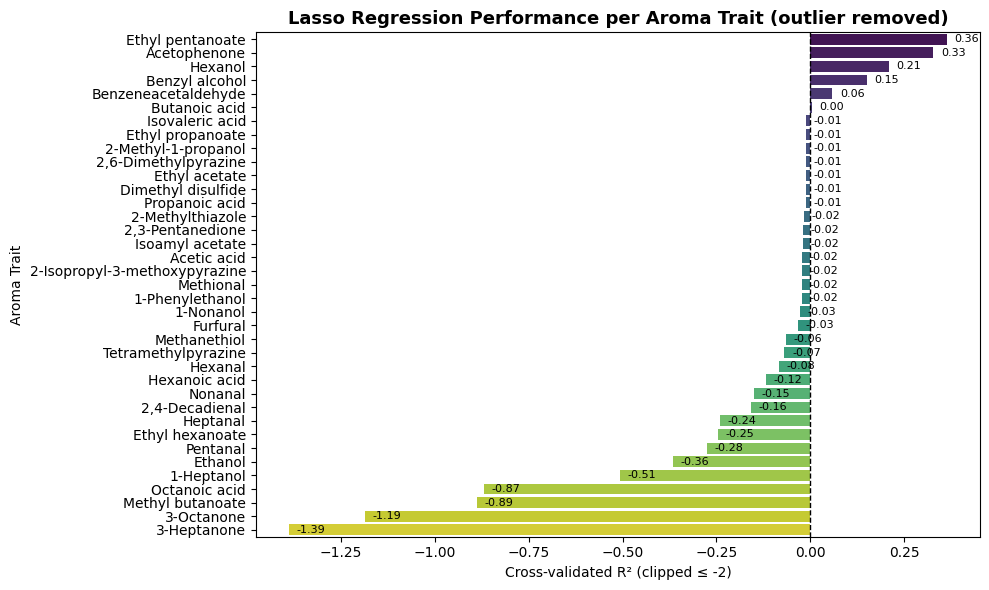

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1783: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\elasticnet_plot_outlier_removed.png


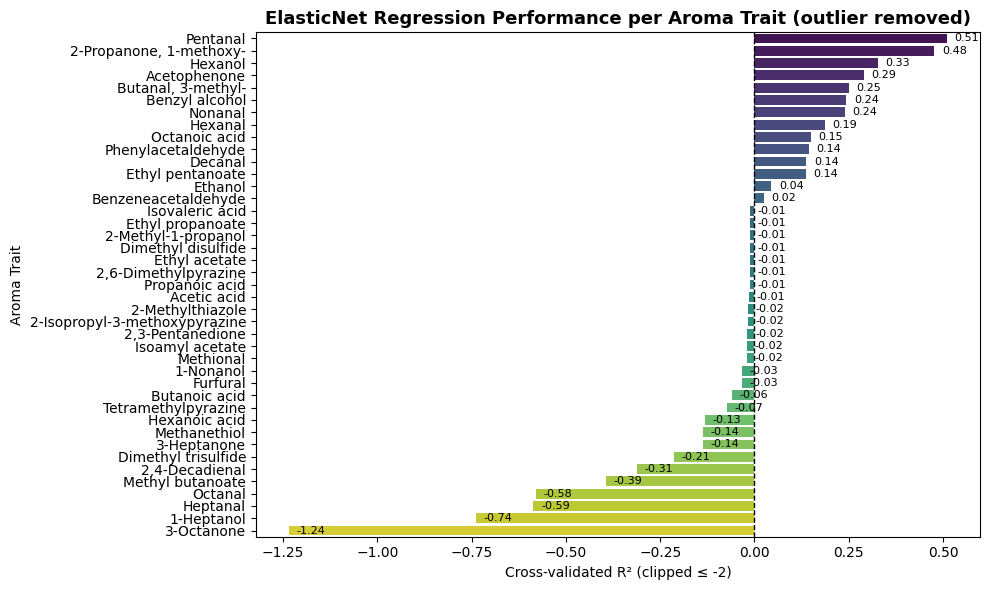

,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
0,1-Heptanol,Linear,1,-0.577092,0.770754,2.977106e+10,1.725429e+05,38515.787529
1,1-Heptanol,Ridge,1,-0.526657,0.770668,2.978215e+10,1.725751e+05,39177.064522
2,1-Heptanol,Lasso,1,-0.505721,0.770754,2.977106e+10,1.725429e+05,38515.847099
3,1-Heptanol,ElasticNet,1,-0.739134,0.757641,3.147399e+10,1.774091e+05,46709.897904
4,1-Nonanol,Linear,1,0.032972,0.984149,5.284044e+07,7.269143e+03,3191.317983
...,...,...,...,...,...,...,...,...
183,Propanoic acid,ElasticNet,1,-0.011111,0.982985,7.544000e+06,2.746634e+03,563.565590
184,Tetramethylpyrazine,Linear,1,-0.554890,0.463157,1.084807e+12,1.041541e+06,853614.631417
185,Tetramethylpyrazine,Ridge,1,-0.069328,0.463106,1.084911e+12,1.041591e+06,855075.016340
186,Tetramethylpyrazine,Lasso,1,-0.068970,0.463157,1.084807e+12,1.041541e+06,853614.674439


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import detect_outliers_aroma_genefrom_plsr , run_linear_models_gene_aroma

# Detect outliers
outlier_samples = detect_outliers_aroma_genefrom_plsr(
    X_scores, Y_scores, merged_snp_aroma.index, z_threshold=3
)

cleaned_data_gene_aroma = merged_snp_aroma.drop(index=outlier_samples)
print(f"Remaining samples after outlier removal: {len(cleaned_data_gene_aroma)}")


# Remove them
cleaned_data_gene_aroma = merged_snp_aroma.drop(index=outlier_samples)
print(f"Remaining samples after outlier removal: {len(cleaned_data_gene_aroma)}")



run_linear_models_gene_aroma(
    gwas_file= r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    snp_df= merged_snp_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep",
    tag="outlier removed"
)




# Nonlinear Modeling of GWAS-Selected SNPs for Aroma Trait Prediction


[Nonlinear Models — full] Trait: 1-Heptanol

[Nonlinear Models — full] Trait: 1-Nonanol

[Nonlinear Models — full] Trait: 1-Octen-3-ol

[Nonlinear Models — full] Trait: 1-Phenylethanol

[Nonlinear Models — full] Trait: 2,3-Pentanedione

[Nonlinear Models — full] Trait: 2,4-Decadienal

[Nonlinear Models — full] Trait: 2,6-Dimethylpyrazine

[Nonlinear Models — full] Trait: 2-Isopropyl-3-methoxypyrazine

[Nonlinear Models — full] Trait: 2-Methyl-1-propanol

[Nonlinear Models — full] Trait: 2-Methylthiazole

[Nonlinear Models — full] Trait: 2-Nonanone

[Nonlinear Models — full] Trait: 2-Propanone, 1-methoxy-

[Nonlinear Models — full] Trait: 3-Heptanone

[Nonlinear Models — full] Trait: 3-Octanone

[Nonlinear Models — full] Trait: Acetic acid

[Nonlinear Models — full] Trait: Acetophenone

[Nonlinear Models — full] Trait: Benzaldehyde

[Nonlinear Models — full] Trait: Benzeneacetaldehyde

[Nonlinear Models — full] Trait: Benzyl alcohol

[Nonlinear Models — full] Trait: Butanal, 3-methyl-


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2024: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\svr_plot_full.png


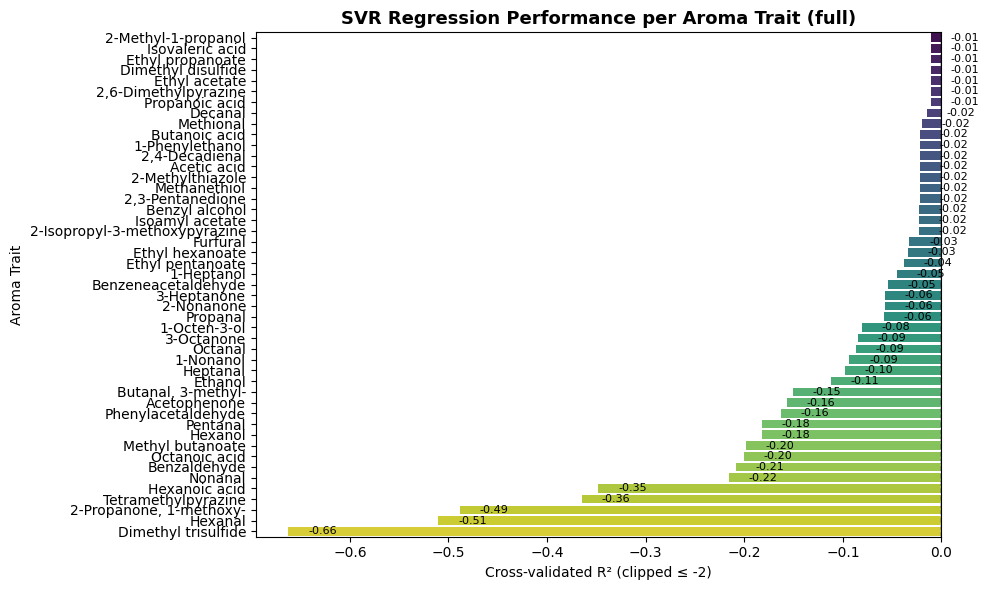

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2024: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\randomforest_plot_full.png


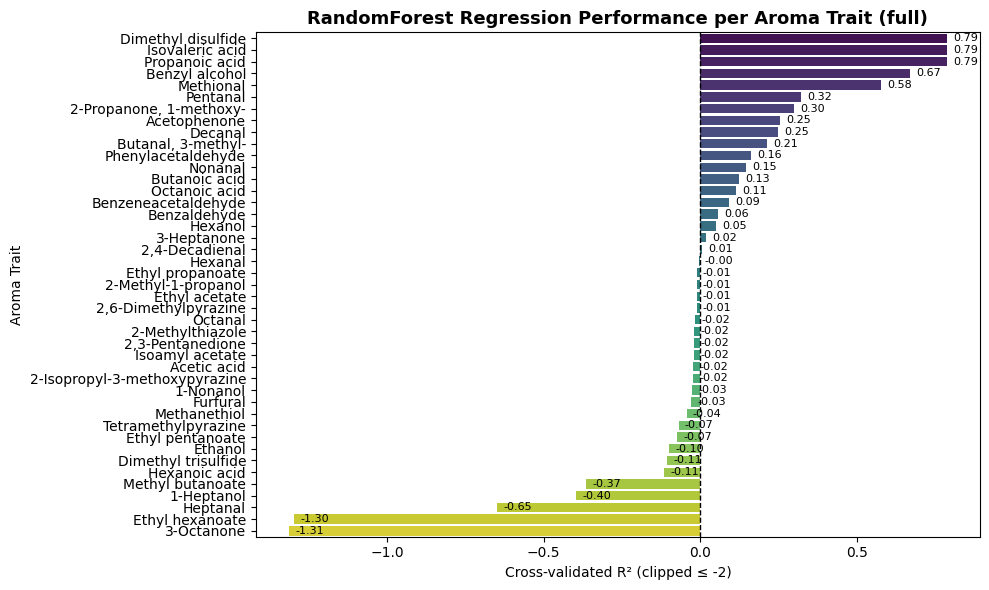

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2024: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\xgboost_plot_full.png


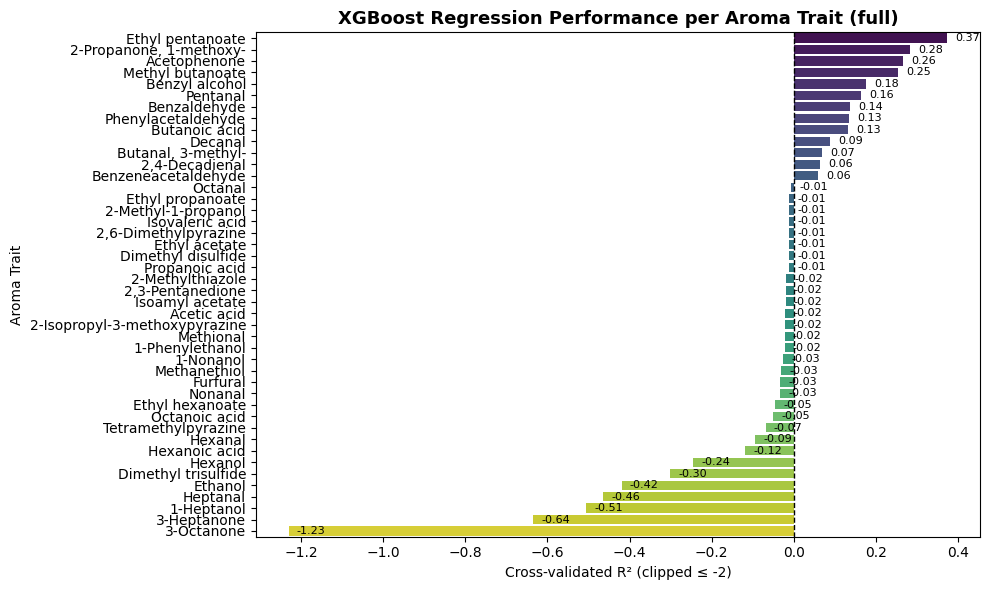

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_models_gene_aroma


results_nonlinear_outlier_removed = run_nonlinear_models_gene_aroma(
    gwas_file=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    snp_df=merged_snp_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep",
    tag="full"
)


# Nonlinear Modeling After Outlier Removal


[Nonlinear Models — outlier removed] Trait: 1-Heptanol

[Nonlinear Models — outlier removed] Trait: 1-Nonanol

[Nonlinear Models — outlier removed] Trait: 1-Octen-3-ol

[Nonlinear Models — outlier removed] Trait: 1-Phenylethanol

[Nonlinear Models — outlier removed] Trait: 2,3-Pentanedione

[Nonlinear Models — outlier removed] Trait: 2,4-Decadienal

[Nonlinear Models — outlier removed] Trait: 2,6-Dimethylpyrazine

[Nonlinear Models — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[Nonlinear Models — outlier removed] Trait: 2-Methyl-1-propanol

[Nonlinear Models — outlier removed] Trait: 2-Methylthiazole

[Nonlinear Models — outlier removed] Trait: 2-Nonanone

[Nonlinear Models — outlier removed] Trait: 2-Propanone, 1-methoxy-

[Nonlinear Models — outlier removed] Trait: 3-Heptanone

[Nonlinear Models — outlier removed] Trait: 3-Octanone

[Nonlinear Models — outlier removed] Trait: Acetic acid

[Nonlinear Models — outlier removed] Trait: Acetophenone

[Nonlinear Models — outlie

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2024: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\svr_plot_outlier_removed.png


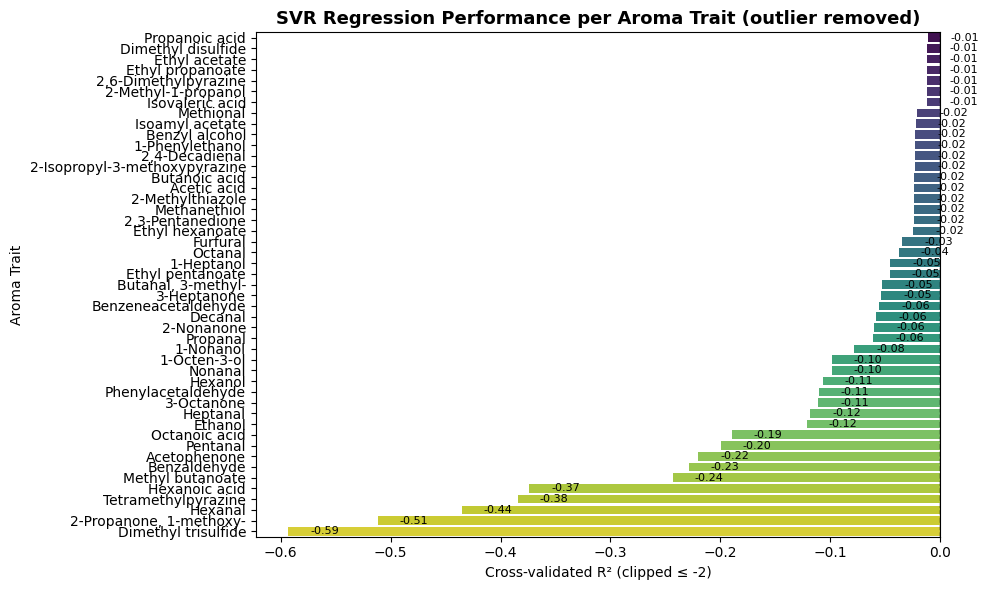

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2024: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\randomforest_plot_outlier_removed.png


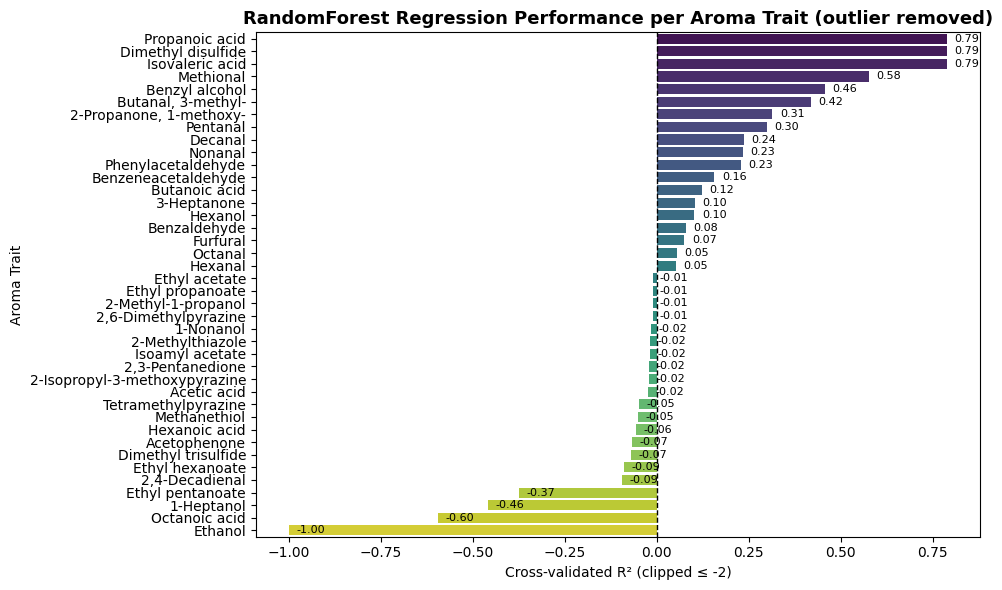

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2024: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\xgboost_plot_outlier_removed.png


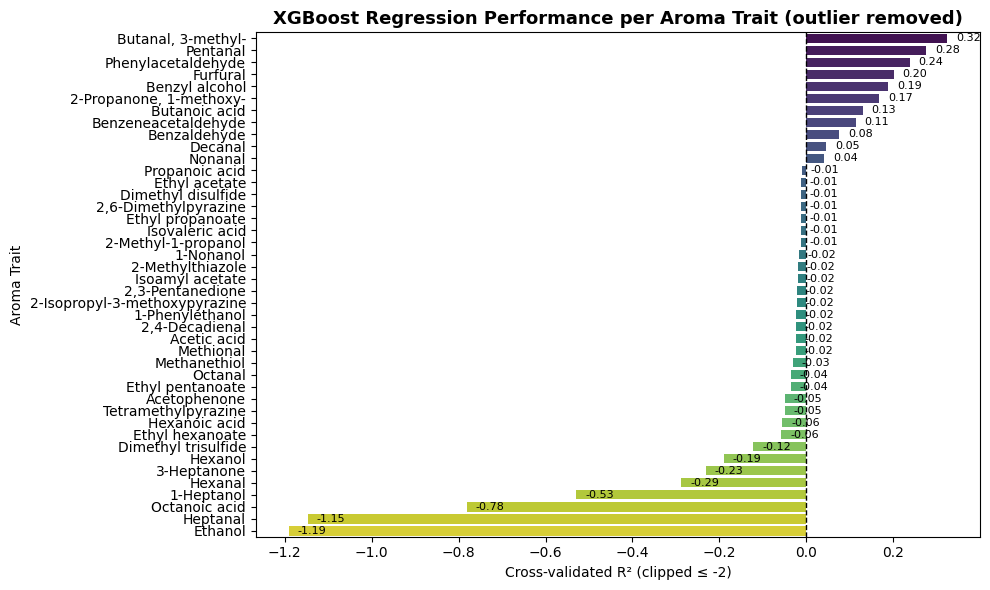

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_models_gene_aroma



results_nonlinear_outlier_removed = run_nonlinear_models_gene_aroma(
    gwas_file=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep",
    tag="outlier removed"
)

# Cross-Validated Kernel Ridge Regression Framework for GWAS Trait Modeling”


[KRR — full] Trait: 1-Heptanol

[KRR — full] Trait: 1-Nonanol

[KRR — full] Trait: 1-Octen-3-ol

[KRR — full] Trait: 1-Phenylethanol

[KRR — full] Trait: 2,3-Pentanedione

[KRR — full] Trait: 2,4-Decadienal

[KRR — full] Trait: 2,6-Dimethylpyrazine

[KRR — full] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — full] Trait: 2-Methyl-1-propanol

[KRR — full] Trait: 2-Methylthiazole

[KRR — full] Trait: 2-Nonanone

[KRR — full] Trait: 2-Propanone, 1-methoxy-

[KRR — full] Trait: 3-Heptanone

[KRR — full] Trait: 3-Octanone

[KRR — full] Trait: Acetic acid

[KRR — full] Trait: Acetophenone

[KRR — full] Trait: Benzaldehyde

[KRR — full] Trait: Benzeneacetaldehyde

[KRR — full] Trait: Benzyl alcohol

[KRR — full] Trait: Butanal, 3-methyl-

[KRR — full] Trait: Butanoic acid

[KRR — full] Trait: Decanal

[KRR — full] Trait: Dimethyl disulfide

[KRR — full] Trait: Dimethyl trisulfide

[KRR — full] Trait: Ethanol

[KRR — full] Trait: Ethyl acetate

[KRR — full] Trait: Ethyl hexanoate

[KRR — full] 

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1903: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_models_plot_full.png


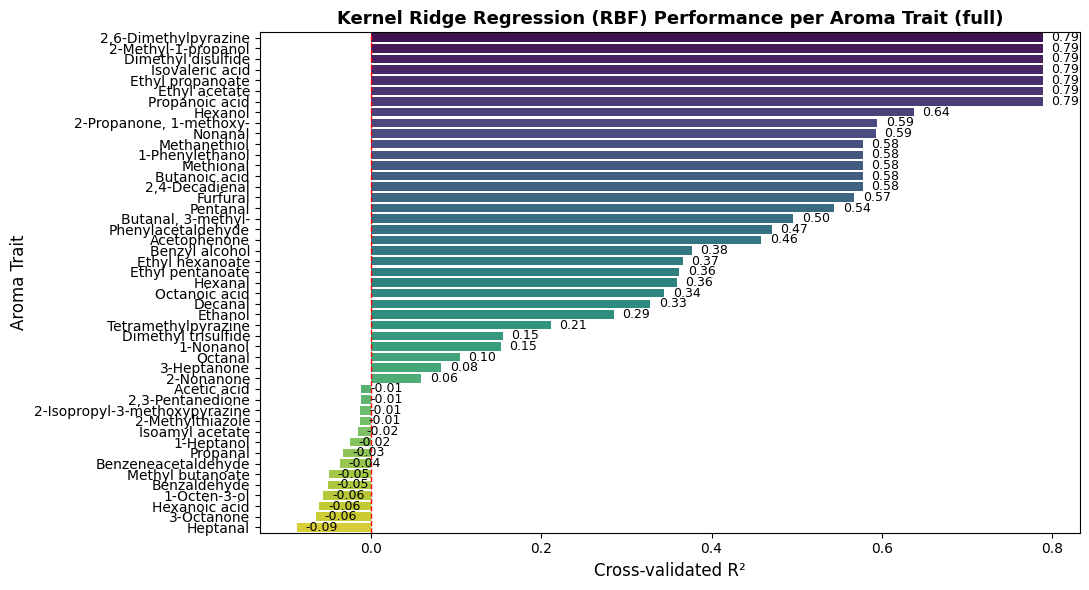

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_krr_models_gene_aroma


results_krr= run_krr_models_gene_aroma(
    gwas_file=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    snp_df=merged_snp_aroma,
    top_n_snps=2000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep",
    tag="full"
)



# KRR Modeling After Outlier Removal


[KRR — outlier removed] Trait: 1-Heptanol

[KRR — outlier removed] Trait: 1-Nonanol

[KRR — outlier removed] Trait: 1-Octen-3-ol

[KRR — outlier removed] Trait: 1-Phenylethanol

[KRR — outlier removed] Trait: 2,3-Pentanedione

[KRR — outlier removed] Trait: 2,4-Decadienal

[KRR — outlier removed] Trait: 2,6-Dimethylpyrazine

[KRR — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — outlier removed] Trait: 2-Methyl-1-propanol

[KRR — outlier removed] Trait: 2-Methylthiazole

[KRR — outlier removed] Trait: 2-Nonanone

[KRR — outlier removed] Trait: 2-Propanone, 1-methoxy-

[KRR — outlier removed] Trait: 3-Heptanone

[KRR — outlier removed] Trait: 3-Octanone

[KRR — outlier removed] Trait: Acetic acid

[KRR — outlier removed] Trait: Acetophenone

[KRR — outlier removed] Trait: Benzaldehyde

[KRR — outlier removed] Trait: Benzeneacetaldehyde

[KRR — outlier removed] Trait: Benzyl alcohol

[KRR — outlier removed] Trait: Butanal, 3-methyl-

[KRR — outlier removed] Trait: Butanoic

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1903: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_models_plot_outlier_removed.png


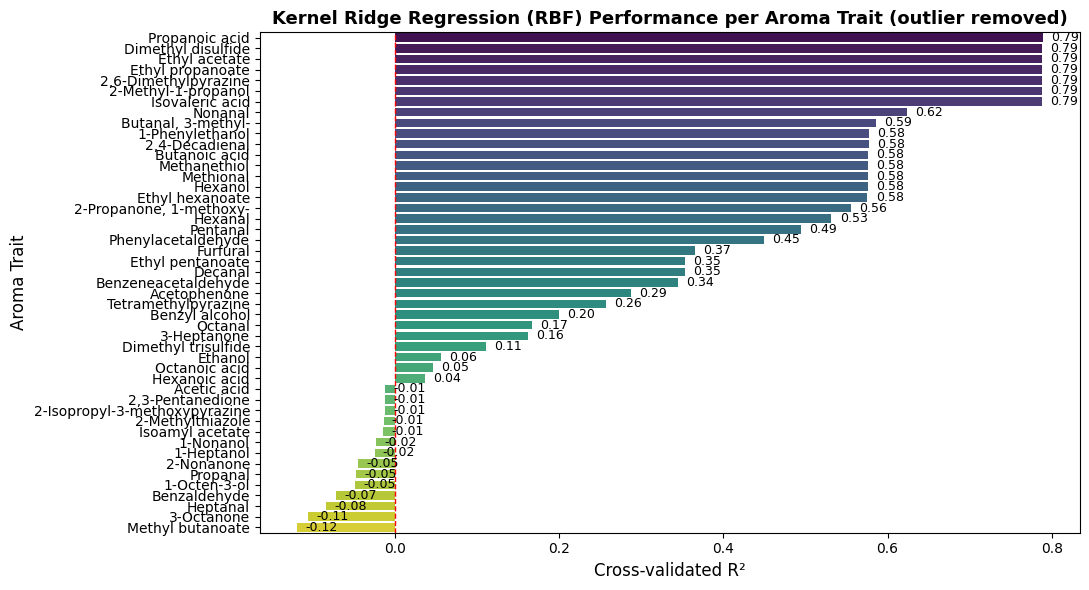

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  run_krr_models_gene_aroma

results_krr_outlier_removed = run_krr_models_gene_aroma(
    gwas_file=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,
    top_n_snps=2000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep",
    tag="outlier removed"
)


# Linear Modeling of Sensory Principal Components Using GWAS-Derived Genetic Markers in Potato Varieties


[Linear Models] Trait: PC1
  Significant SNPs found: 289

[Linear Models] Trait: PC2
  No SNPs with FDR < 0.1. Using top 1000 by p-value.

[Linear Models] Trait: PC3
  No SNPs with FDR < 0.1. Using top 1000 by p-value.

 Linear model results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\linear_models_sensory_PCs_FDR05.csv


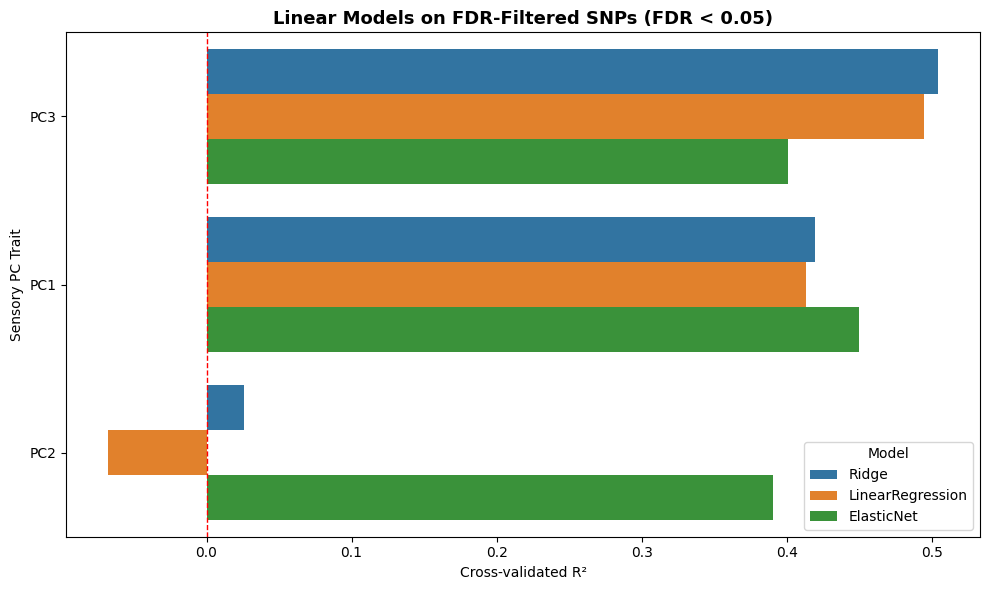

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  run_linear_models_sensory



results_sensory = run_linear_models_sensory(
    gwas_file=gwas_output_sensory,
    merged_snp_df=merged_snp_sensory,
    fdr_threshold=0.1,
    top_n_fallback=1000,
    prune_threshold=0.9,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)



# Nonlinear Modeling of Sensory Principal Components Using Kernel Ridge Regression (RBF Kernel)”


[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 289

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.1. Using top 1000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.1. Using top 1000 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2264: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_sensory_PCs_plot_FDRfiltered.png


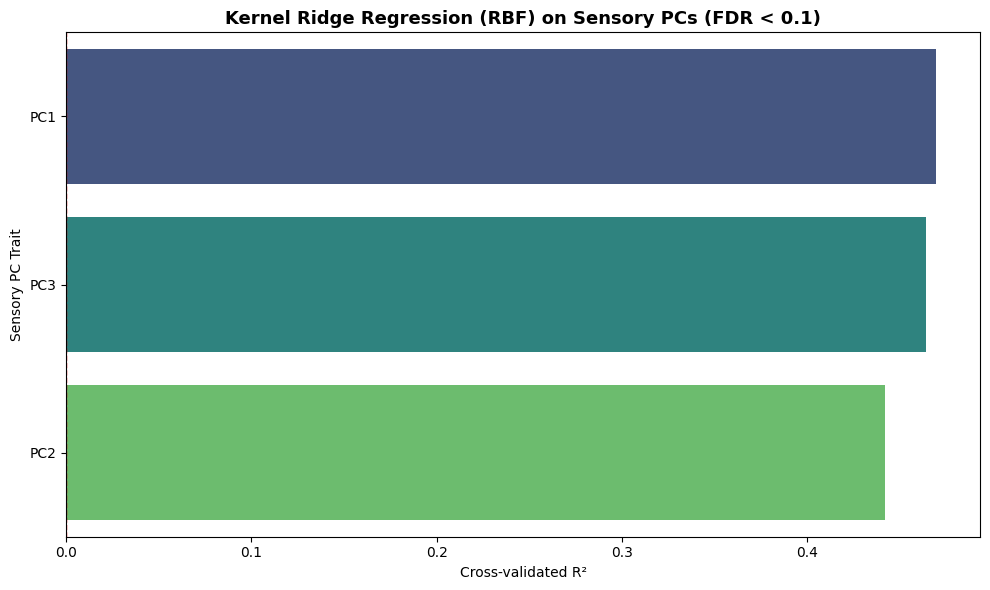

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_krr_sensory_pcs


results_krr_fdr10 = run_krr_sensory_pcs(
    gwas_file=gwas_output_sensory,
    merged_snp_df=merged_snp_sensory,
    fdr_threshold=0.1,
    top_n_fallback=1000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)


# Nonlinear Modeling of Sensory Principal Components Using SVR, Random Forest, and XGBoost


[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 289
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.1. Using top 1000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.1. Using top 1000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

 Nonlinear model results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\nonlinear_models_sensory_PCs_FDRfiltered.csv
 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\nonlinear_sensory_PCs_plot_FDRfiltered.png


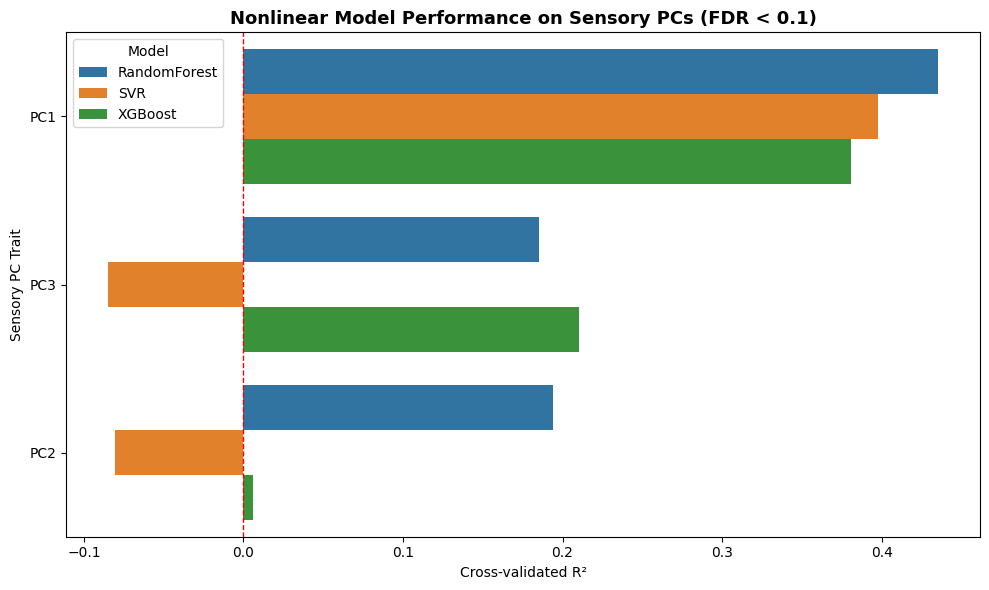

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_sensory_pcs




results_nonlinear_fdr10 = run_nonlinear_sensory_pcs(
    gwas_file=gwas_output_sensory,
    merged_snp_df=merged_snp_sensory,
    fdr_threshold=0.1,
    top_n_fallback=1000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)


# Modeling After Outlier Removal

 No SNPs with FDR < 0.05. Using top 500 by p-value.


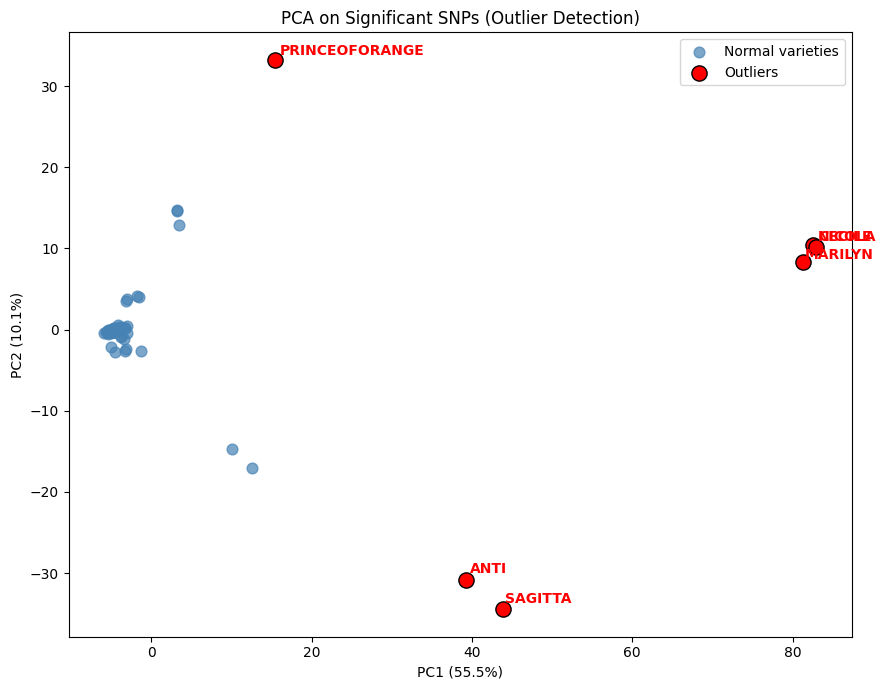

Detected PCA Outliers: ['ANTI', 'CECILE', 'MARILYN', 'NICOLA', 'PRINCEOFORANGE', 'SAGITTA']
 Removed 6 outliers. Remaining: 88 samples.

[Linear Models] Trait: PC1
  No SNPs with FDR < 0.05. Using top 500 by p-value.

[Linear Models] Trait: PC2
  No SNPs with FDR < 0.05. Using top 500 by p-value.

[Linear Models] Trait: PC3
  No SNPs with FDR < 0.05. Using top 500 by p-value.

 Linear model results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\linear_models_sensory_PCs_FDR05.csv


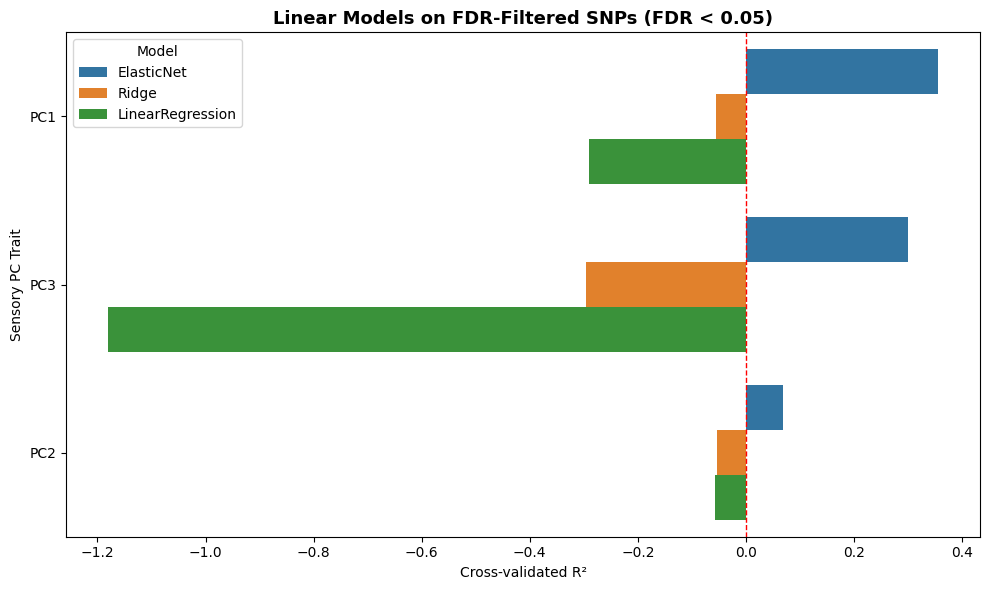


[Linear Models] Trait: PC1
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

[Linear Models] Trait: PC2
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

[Linear Models] Trait: PC3
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

 Linear model results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\linear_models_sensory_PCs_FDR05.csv


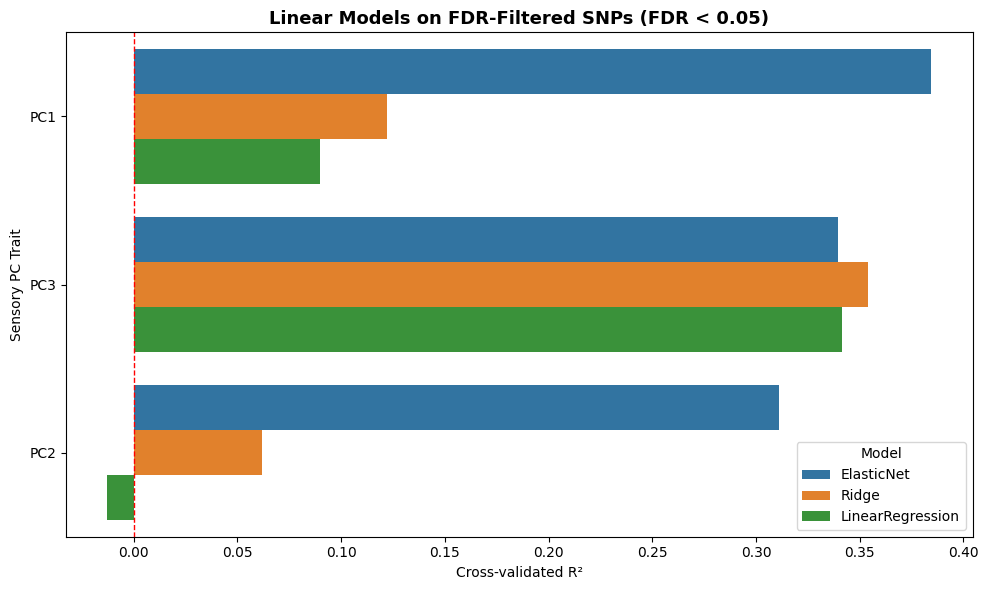


[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:2264: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_sensory_PCs_plot_FDRfiltered.png


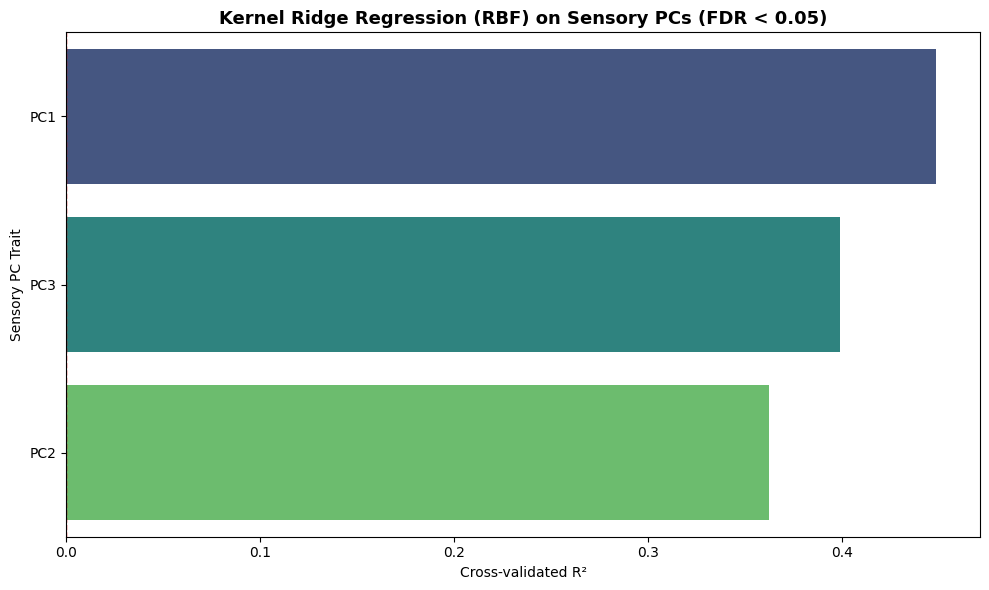


[Nonlinear Models - Sensory PCs] Trait: PC1
  No SNPs with FDR < 0.05. Using top 1000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 1000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 1000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

 Nonlinear model results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\nonlinear_models_sensory_PCs_FDRfiltered.csv
 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\nonlinear_sensory_PCs_plot_FDRfiltered.png


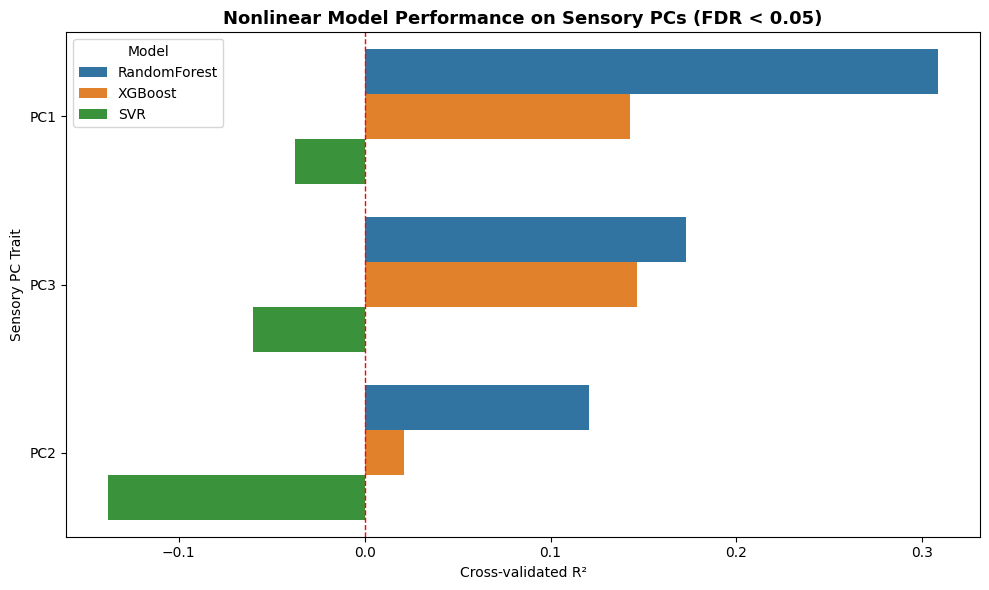

In [ ]:


# 1. Run PCA and detect outliers
results_pca = analyze_gwas_snps_pca(
    gwas_path=gwas_output_sensory,
    merged_snp_sensory=merged_snp_sensory
)

# 2. Extract outliers
pca_outliers = results_pca["pca_outliers"]
print(f"Detected PCA Outliers: {pca_outliers}")

# 3. Remove outliers
cleaned_snp_sensory = merged_snp_sensory.drop(
    index=[o for o in pca_outliers if o in merged_snp_sensory.index]
)
print(f" Removed {len(pca_outliers)} outliers. Remaining: {cleaned_snp_sensory.shape[0]} samples.")

results_linear_fdr05 = run_linear_models_sensory(
    gwas_file=gwas_output_sensory,
    merged_snp_df=cleaned_snp_sensory,
    fdr_threshold=0.05,       # can set to 0.1 if desired
    top_n_fallback=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)



results_sensory = run_linear_models_sensory(
    gwas_file=gwas_output_sensory,
    merged_snp_df=cleaned_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=1000,
    prune_threshold=0.9,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)



results_krr_fdr10 = run_krr_sensory_pcs(
    gwas_file=gwas_output_sensory,
    merged_snp_df=cleaned_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=1000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)

results_nonlinear_fdr10 = run_nonlinear_sensory_pcs(
    gwas_file=gwas_output_sensory,
    merged_snp_df= cleaned_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=1000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)


# Correlation Analysis Between Gene-Predicted Aroma Compounds and Sensory Principal Components

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import correlate_gene_predictions_with_sensory_pcs




corr_matrix_outlier_removed = correlate_gene_predictions_with_sensory_pcs(
    gwas_file=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,  # 92 samples
    merged_snp_sensory=merged_snp_sensory,  # 94 samples (will auto-align)
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep",
    top_n_snps=2000,
    prune_threshold=0.95,
    r2_threshold=0.5,
    tag="outlier_removed"
)


NameError: name 'cleaned_data_gene_aroma' is not defined

# Analysis of Gene Marker Effects for Top Correlated Aroma–Sensory Traits


 Found 12 high-correlation compounds (|r| ≥ 0.1):
→ ['Nonanal', 'Butanal, 3-methyl-', 'Ethyl hexanoate', 'Hexanol', '2-Propanone, 1-methoxy-', 'Methional', 'Isovaleric acid', 'Dimethyl disulfide', 'Propanoic acid', 'Butanoic acid', 'Methanethiol', 'Hexanal']

 Analyzing 2-Propanone, 1-methoxy- (20 SNPs)...


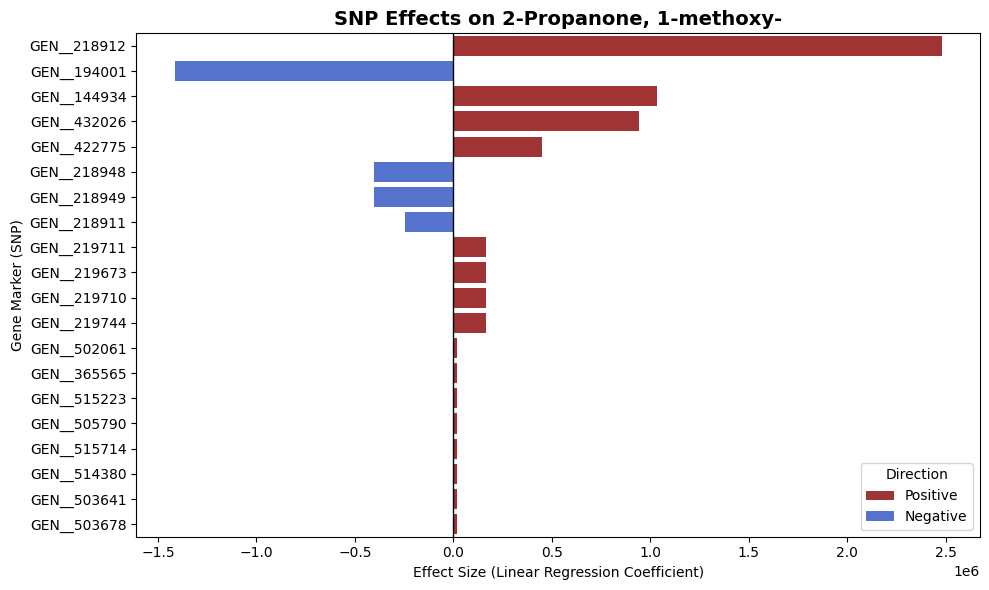


 Analyzing Butanal, 3-methyl- (20 SNPs)...


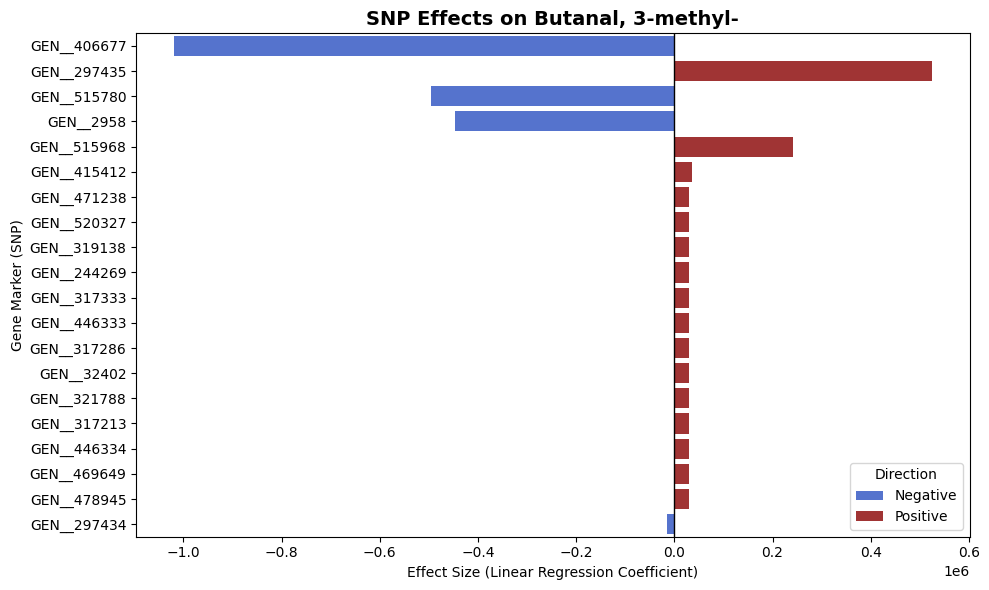


 Analyzing Butanoic acid (20 SNPs)...


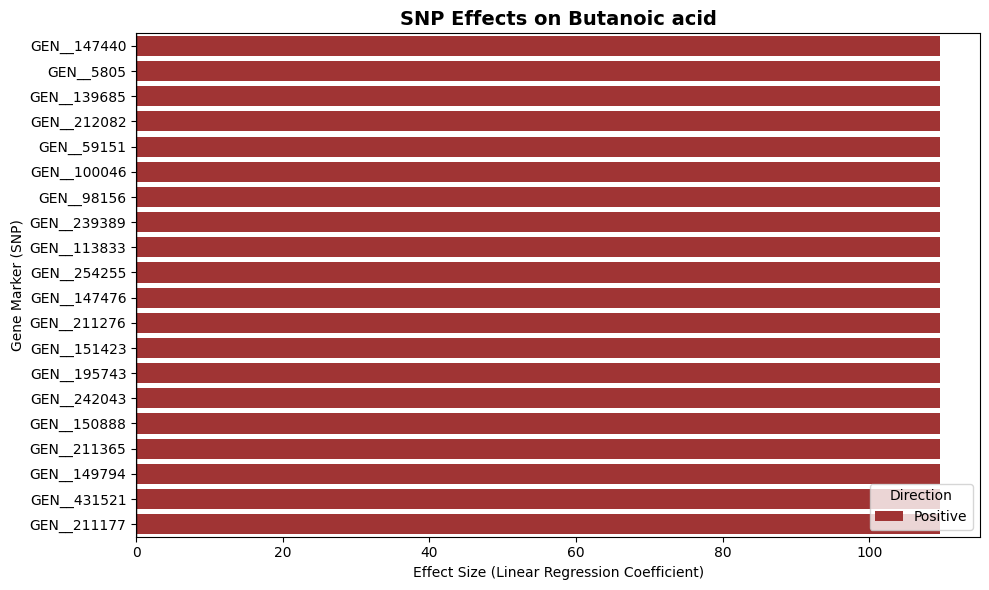


 Analyzing Dimethyl disulfide (20 SNPs)...


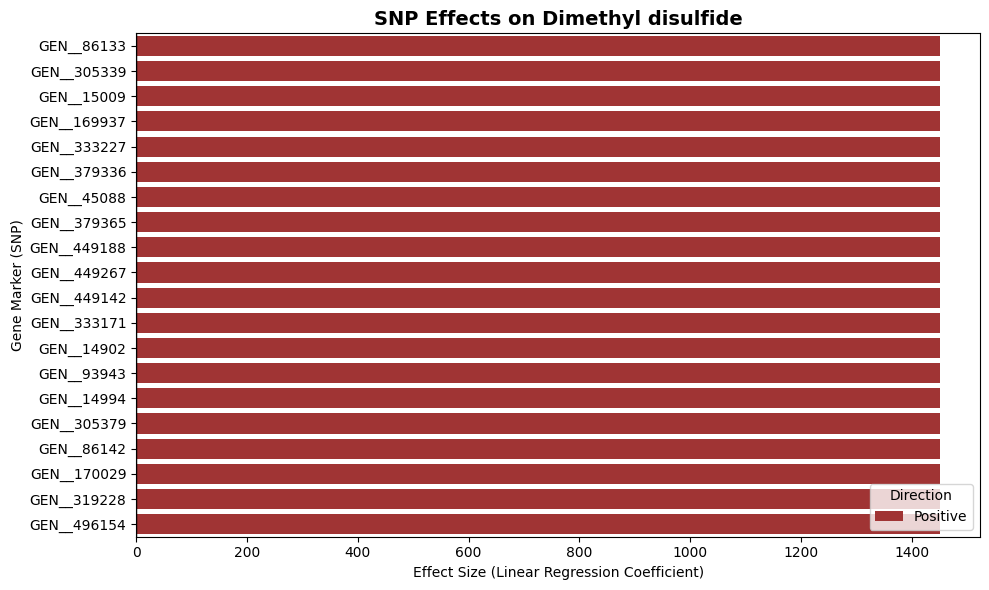


 Analyzing Ethyl hexanoate (20 SNPs)...


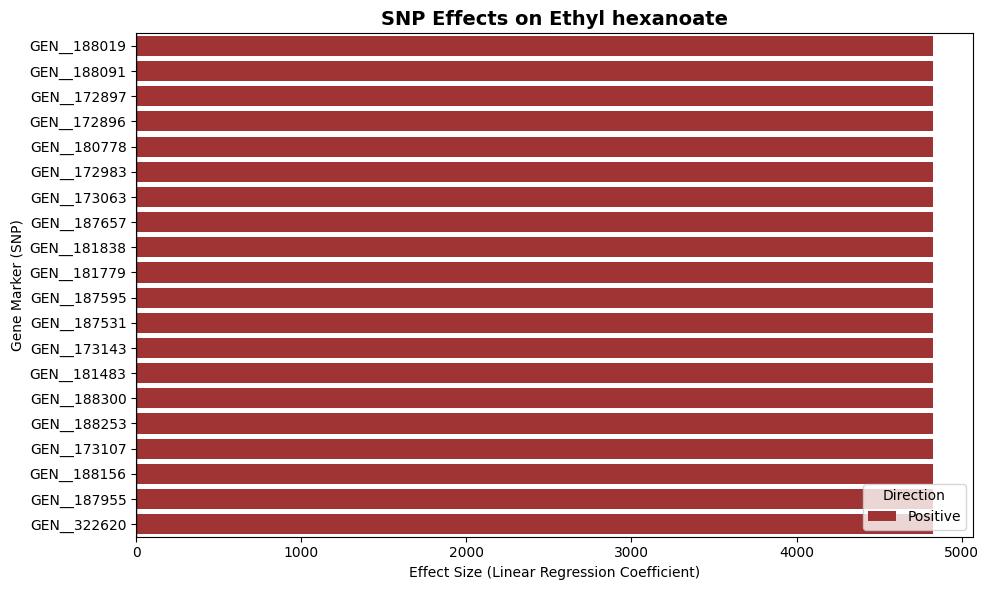


 Analyzing Hexanal (20 SNPs)...


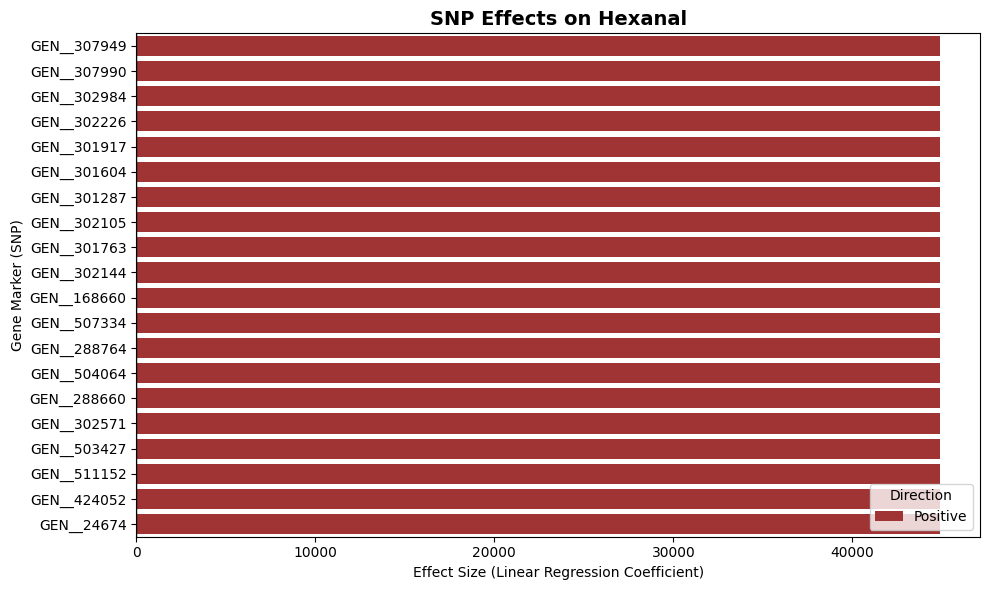


 Analyzing Hexanol (20 SNPs)...


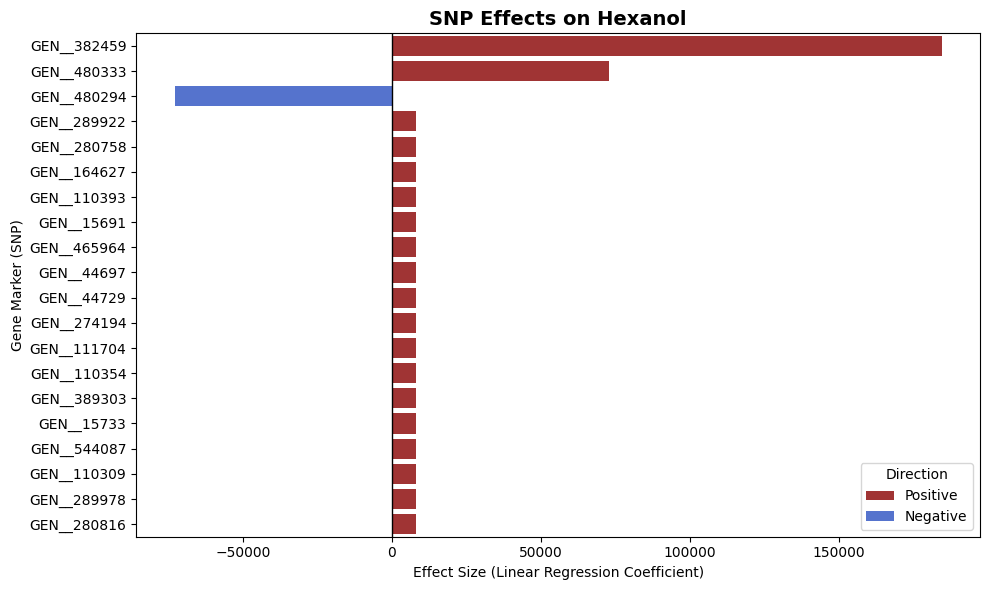


 Analyzing Isovaleric acid (20 SNPs)...


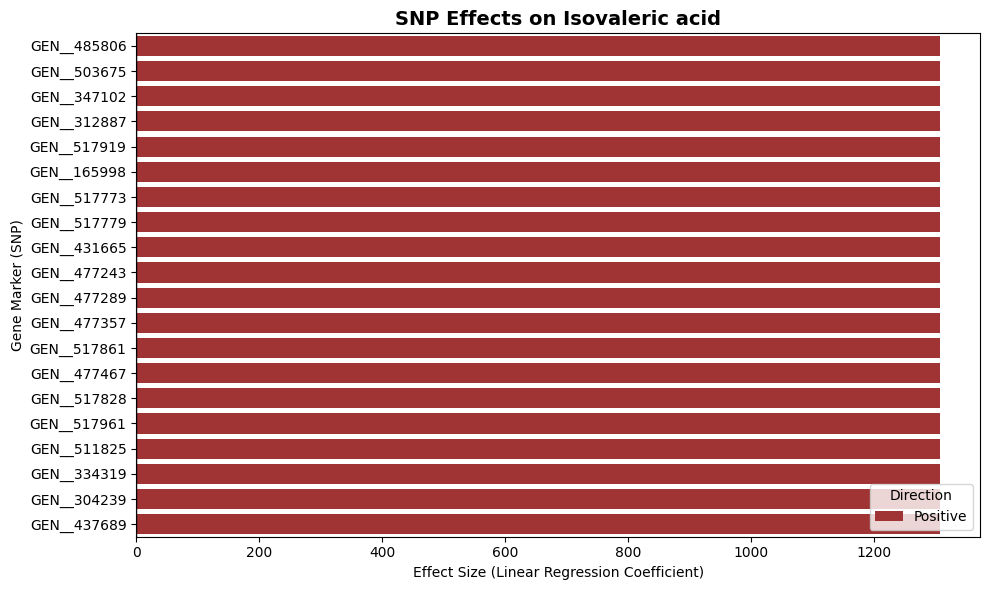


 Analyzing Methanethiol (20 SNPs)...


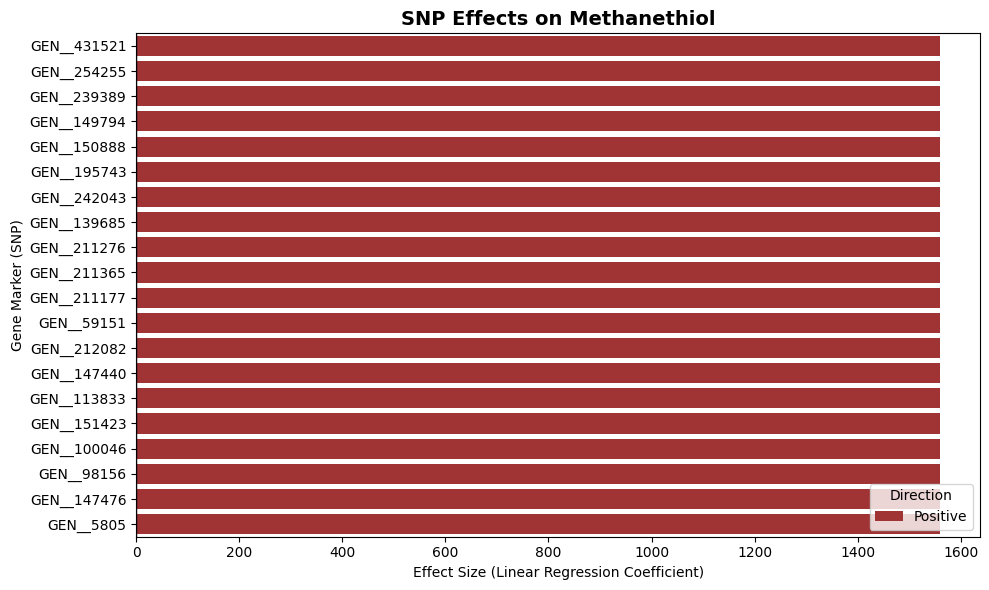


 Analyzing Methional (20 SNPs)...


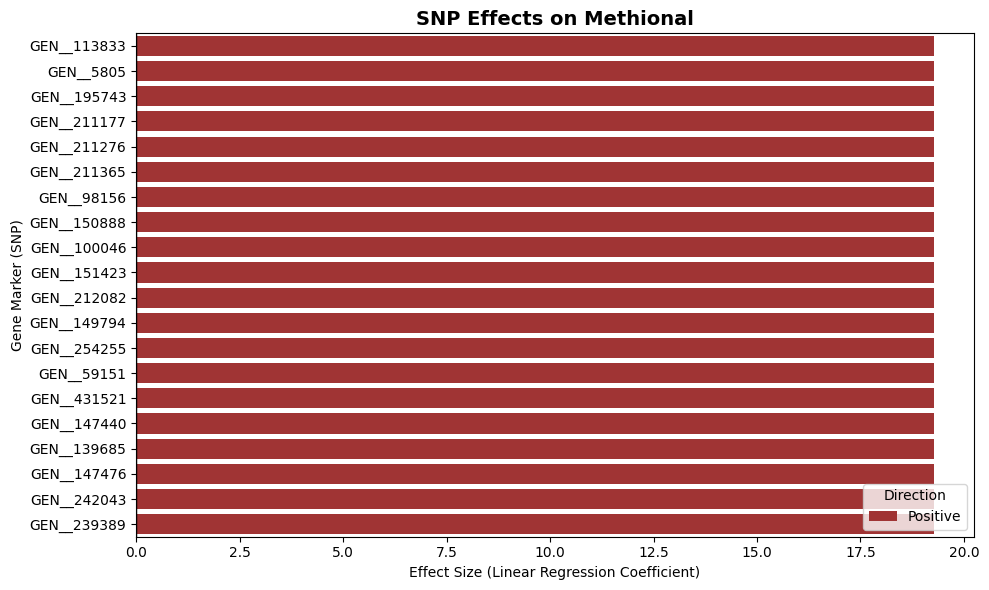


 Analyzing Nonanal (20 SNPs)...


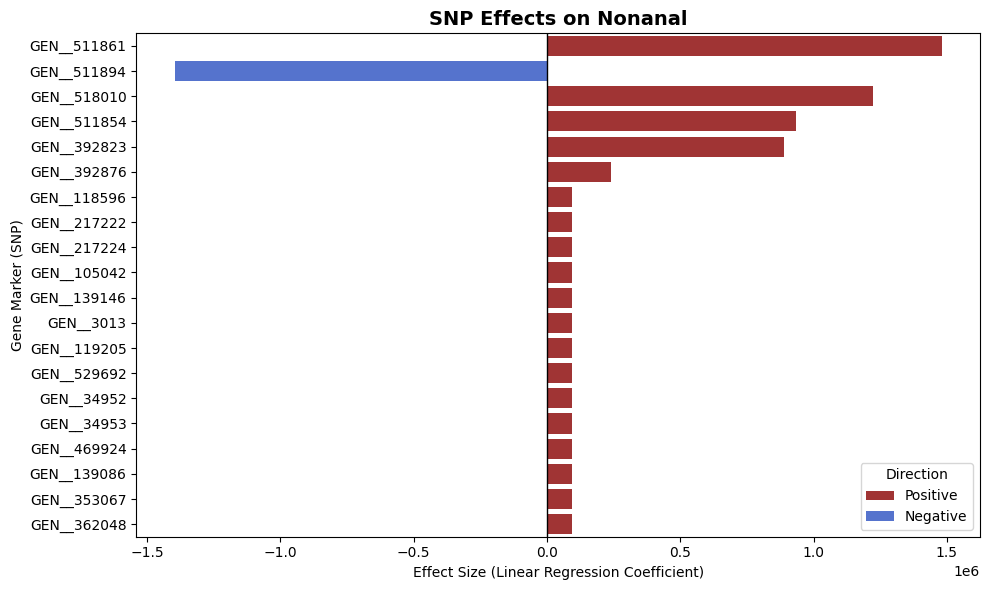


 Analyzing Propanoic acid (20 SNPs)...


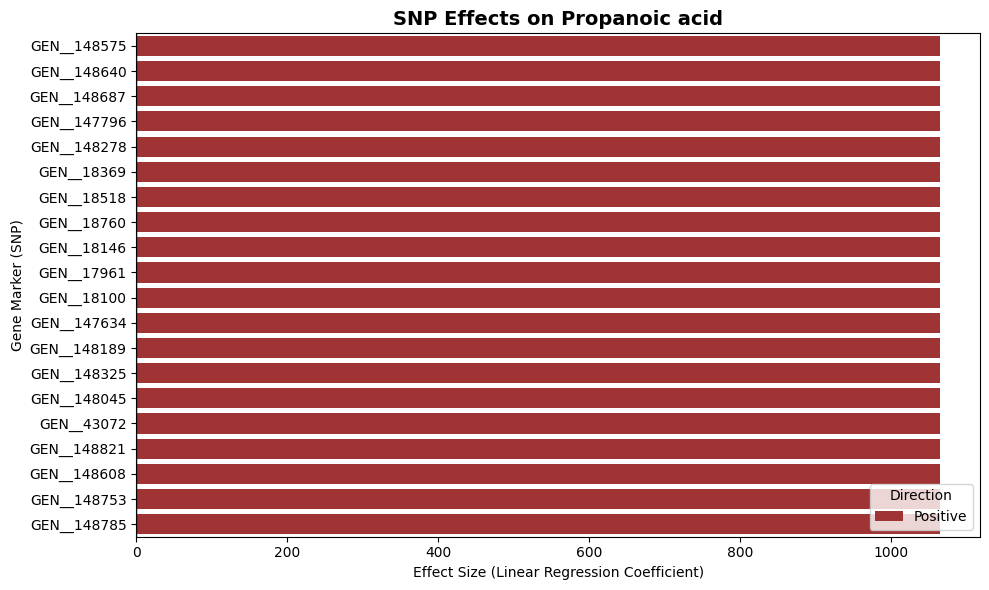


 Finished analyzing SNP effects for high-correlation traits.


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  analyze_marker_effects_for_top_correlated_traits


effects_summary = analyze_marker_effects_for_top_correlated_traits(
    gwas_file=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv",
    df_aroma=cleaned_data_gene_aroma,
    corr_matrix=corr_matrix_outlier_removed,
    corr_threshold=0.1,
    top_snps_per_trait=20,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import reconstruct_sensory_traits_from_pca


sensory_reconstructed_df = reconstruct_sensory_traits_from_pca(
    projection_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_projection.csv",
    loadings_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_loadings.csv",
    save_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv",
    n_components=3
)


 Reconstructed sensory traits using 3 PCs:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
Variety,,,,,,,,,,,,,,,,,,,,
ADORA,2.777227,3.021468,2.221376,2.850300,-1.066084,-0.847148,2.373826,2.495142,2.784747,3.016634,-1.006645,0.899148,1.878034,-0.157331,0.828773,1.786741,-0.069789,-0.149353,-0.225817,2.325663
AGRIA,-0.229637,-0.448615,0.509891,-0.827166,-0.731611,-1.171877,0.083648,0.310391,-0.388611,-1.042706,-1.130200,1.387898,-0.340720,-0.651435,1.694207,-0.093582,-0.849283,-1.680008,2.088016,0.320938
BERBER,-0.354242,-0.459819,0.098332,-0.640353,0.861787,0.459095,0.873152,0.428063,-0.596838,-0.754492,0.370748,-0.125063,-0.278329,1.418112,1.733750,-1.048533,1.192578,-0.023029,1.404938,-0.173067
BILDTSTAR,-0.143122,-0.293976,0.317844,-0.535582,-0.939388,-1.155316,-0.367521,0.003764,-0.178766,-0.677375,-1.078262,1.199855,-0.238350,-1.130382,0.698996,0.290940,-1.208747,-1.412395,1.204038,0.265307
BINTJE,-0.896907,-1.004481,-0.571348,-1.026723,0.614686,0.401464,-0.323025,-0.523106,-0.990835,-1.116110,0.412158,-0.289270,-0.621746,0.574778,0.430797,-0.885742,0.465161,0.026589,0.598025,-0.702797


 Saved reconstructed sensory traits → C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv


# PLSR Analysis Between High-Predictive Gene-Based Compounds and Reconstructed Sensory Attributes


[KRR — default] Trait: 1-Heptanol

[KRR — default] Trait: 1-Nonanol

[KRR — default] Trait: 1-Octen-3-ol

[KRR — default] Trait: 1-Phenylethanol

[KRR — default] Trait: 2,3-Pentanedione

[KRR — default] Trait: 2,4-Decadienal

[KRR — default] Trait: 2,6-Dimethylpyrazine

[KRR — default] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — default] Trait: 2-Methyl-1-propanol

[KRR — default] Trait: 2-Methylthiazole

[KRR — default] Trait: 2-Nonanone

[KRR — default] Trait: 2-Propanone, 1-methoxy-

[KRR — default] Trait: 3-Heptanone

[KRR — default] Trait: 3-Octanone

[KRR — default] Trait: Acetic acid

[KRR — default] Trait: Acetophenone

[KRR — default] Trait: Benzaldehyde

[KRR — default] Trait: Benzeneacetaldehyde

[KRR — default] Trait: Benzyl alcohol

[KRR — default] Trait: Butanal, 3-methyl-

[KRR — default] Trait: Butanoic acid

[KRR — default] Trait: Decanal

[KRR — default] Trait: Dimethyl disulfide

[KRR — default] Trait: Dimethyl trisulfide

[KRR — default] Trait: Ethanol

[KRR — def

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\genemarker_module.py:1903: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed_biorep\krr_models_plot_default.png


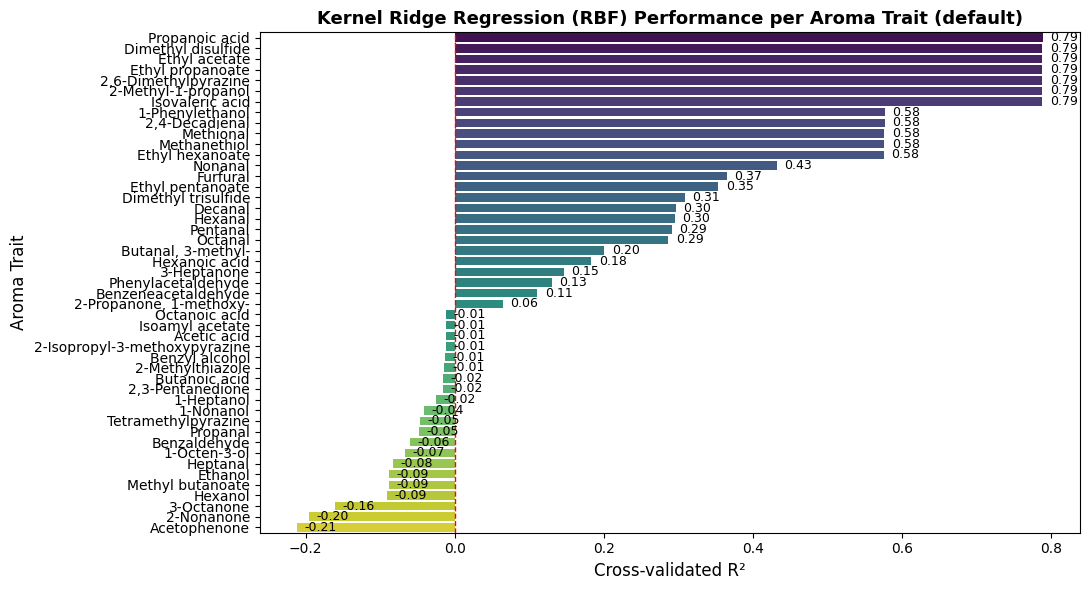

ValueError: too many values to unpack (expected 2)

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_plsr_gene_predicted_vs_sensory,run_krr_models_gene_aroma




high_r2_traits = results_krr_outlier_removed.query("CV_Best_R2 >= 0.5")["Trait"].tolist()
results_krr, predictions = run_krr_models_gene_aroma(
        gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
        snp_df=cleaned_data_gene_aroma,
        top_n_snps=1000,
        prune_threshold=0.95,
        save_dir=r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed_biorep',
        tag='default'
    )

pls_results = run_plsr_gene_predicted_vs_sensory(
    predictions=predictions,
    sensory_reconstructed_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv",
    high_r2_traits=high_r2_traits,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship",
    n_components=5
)


# PLSR Analysis Between Gene-Predicted Aroma Compounds and Sensory Attribute biplot

✅ Common varieties found: 83
X_scaled shape: (83, 18), Y_scaled shape: (83, 20)
📈 PLS model fitted successfully!


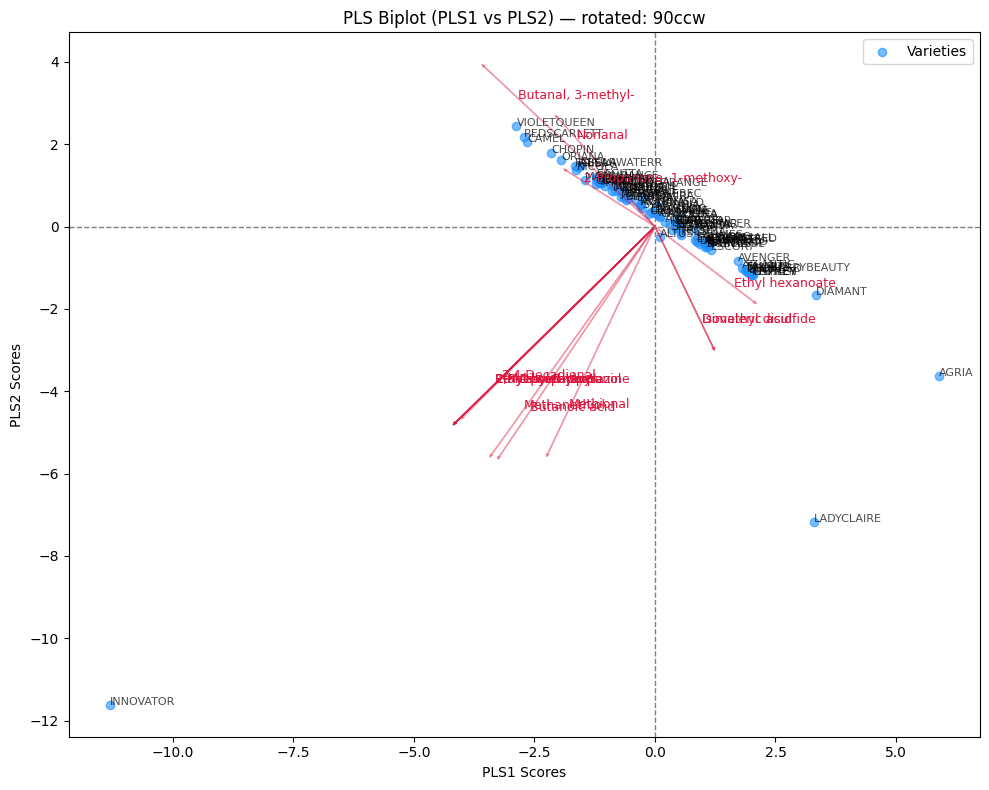

In [ ]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  prepare_plsr_data, plot_plsr_biplot


#Prepare data and fit PLS


high_r2_traits = results_krr_outlier_removed.query("CV_Best_R2 >= 0.5")["Trait"].tolist()
results_krr, predictions = run_krr_models_gene_aroma(
        gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
        snp_df=cleaned_data_gene_aroma,
        top_n_snps=1000,
        prune_threshold=0.95,
        save_dir=r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed_biorep',
        tag='default'
    )

#  Make sure 'predictions' and 'high_r2_traits' already exist in memory
X, Y, X_scaled, Y_scaled = prepare_plsr_data(predictions, high_r2_traits, sensory_reconstructed_path)

# Fit PLS model
pls = PLSRegression(n_components=5)
pls.fit(X_scaled, Y_scaled)
print(" PLS model fitted successfully!")


# Visualize PLS biplot

plot_plsr_biplot(
    pls_model=pls,
    X_scaled=pd.DataFrame(X_scaled, index=X.index, columns=X.columns),
    pc1=1,
    pc2=2,
    rotate='90ccw',
    top_n_loadings=15,
    scale_arrows=12
)
